# India Post Infrastructure Efficiency Model
### Group 10 | PGP in Data Science with Specialization in GenAI | Batch 2025–26

**Project Title:** Development of a Data-Driven Infrastructure Efficiency Model for Optimizing Postal Delivery Performance

**Methodology:** CRISP-DM | **Problem Type:** Regression | **Target Variable:** `district_delivery_rate`

---

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, HistGradientBoostingRegressor)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Stats
from scipy import stats
from scipy.stats import (chi2_contingency, f_oneway, kruskal, pearsonr, spearmanr,
                          shapiro, mannwhitneyu, levene, ttest_ind)

# Statsmodels (with fallback if not installed)
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.stats.stattools import durbin_watson
    print("statsmodels loaded.")
except ImportError:
    print("statsmodels not found — using manual VIF & Durbin-Watson implementations.")
    def variance_inflation_factor(exog, exog_idx):
        # Manual VIF using sklearn LinearRegression
        from sklearn.linear_model import LinearRegression as _LR
        cols = list(range(exog.shape[1]))
        cols.remove(exog_idx)
        X_other = exog[:, cols]
        y_col = exog[:, exog_idx]
        r2 = _LR().fit(X_other, y_col).score(X_other, y_col)
        return 1.0 / (1.0 - r2) if r2 < 1.0 else np.inf

    def durbin_watson(resids):
        # Manual Durbin-Watson statistic
        resids = np.asarray(resids)
        diff = np.diff(resids)
        return np.sum(diff ** 2) / np.sum(resids ** 2)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 11,
                     'axes.titlesize': 14, 'axes.titleweight': 'bold'})

print("All libraries imported successfully.")

statsmodels not found — using manual VIF & Durbin-Watson implementations.
All libraries imported successfully.


## Step 2: Data Loading — Three Datasets

In [2]:
# ============================================================
# 2a. Load Postal Infrastructure Dataset (Primary — 165,627 records)
# ============================================================
data = pd.read_csv('postal_infrastructure_delivery_dataset.csv', low_memory=False)
print(f"Postal Infrastructure: {data.shape}")
data.head()

Postal Infrastructure: (165627, 11)


,circlename,regionname,divisionname,officename,pincode,officetype,delivery,district,statename,latitude,longitude
0,Telangana Circle,Hyderabad Region,Adilabad Division,Kothimir B.O,504273,BO,Delivery,KUMURAM BHEEM ASIFABAD,TELANGANA,19.3638689,79.5376658
1,Telangana Circle,Hyderabad Region,Adilabad Division,Papanpet B.O,504299,BO,Delivery,KUMURAM BHEEM ASIFABAD,TELANGANA,19.4764899,79.583923
2,Telangana Circle,Hyderabad Region,Adilabad Division,Kukuda B.O,504299,BO,Delivery,KUMURAM BHEEM ASIFABAD,TELANGANA,NaN,NaN
3,Telangana Circle,Hyderabad Region,Adilabad Division,Bareguda B.O,504296,BO,Delivery,KUMURAM BHEEM ASIFABAD,TELANGANA,19.3285752,79.4760132
4,Telangana Circle,Hyderabad Region,Adilabad Division,Mosam B.O,504296,BO,Delivery,KUMURAM BHEEM ASIFABAD,TELANGANA,19.3778044,79.6165209


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165627 entries, 0 to 165626
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   circlename    165627 non-null  object
 1   regionname    165312 non-null  object
 2   divisionname  165627 non-null  object
 3   officename    165627 non-null  object
 4   pincode       165627 non-null  int64 
 5   officetype    165627 non-null  object
 6   delivery      165627 non-null  object
 7   district      164912 non-null  object
 8   statename     164912 non-null  object
 9   latitude      153620 non-null  object
 10  longitude     153625 non-null  object
dtypes: int64(1), object(10)
memory usage: 13.9+ MB


In [4]:
data.describe()

,pincode
count,165627.000000
mean,506840.727333
std,207001.361694
min,110001.000000
25%,341301.000000
50%,503180.000000
75%,690504.500000
max,900099.000000


In [5]:
# Missing values
print("Missing Values (%):")
print(data.isna().mean().mul(100).round(2).to_string())

Missing Values (%):
circlename      0.00
regionname      0.19
divisionname    0.00
officename      0.00
pincode         0.00
officetype      0.00
delivery        0.00
district        0.43
statename       0.43
latitude        7.25
longitude       7.25


In [6]:
# ============================================================
# 2b. Load Complaints Dataset (5 rows — FY 2016-21)
# ============================================================
complaints = pd.read_csv('complaints.csv')
complaints.columns = ['Year', 'Total_Complaints', 'Total_Parcels', 'Complaint_Rate_Percent']
complaints['Year'] = complaints['Year'].astype(str).str[:4].astype(int)
print(f"Complaints: {complaints.shape}")
complaints

Complaints: (5, 4)


,Year,Total_Complaints,Total_Parcels,Complaint_Rate_Percent
0,2016,1048102,34300000,3.06
1,2017,836580,29500000,2.84
2,2018,929710,27100000,3.43
3,2019,711111,30900000,2.30
4,2020,391128,34400000,1.14


In [7]:
# ============================================================
# 2c. Load Statewise Dataset (37 states/UTs)
# ============================================================
statewise = pd.read_csv('statewise.csv')
statewise.columns = ['Sl_No', 'State', 'Head_PO', 'Sub_PO', 'Branch_PO', 'Total_PO']
statewise = statewise[~statewise['State'].astype(str).str.contains('Total|North East:', na=False)]
statewise.drop(columns=['Sl_No'], inplace=True)
statewise['State'] = statewise['State'].astype(str).str.replace(r'^\d+\.?\d*\s*', '', regex=True).str.strip()
for col in ['Head_PO', 'Sub_PO', 'Branch_PO', 'Total_PO']:
    statewise[col] = pd.to_numeric(statewise[col].astype(str).str.replace(',', ''), errors='coerce')
statewise['Head_PO_Ratio'] = statewise['Head_PO'] / statewise['Total_PO']
statewise['Branch_PO_Ratio'] = statewise['Branch_PO'] / statewise['Total_PO']
print(f"Statewise: {statewise.shape}")
statewise.head()

Statewise: (36, 7)


,State,Head_PO,Sub_PO,Branch_PO,Total_PO,Head_PO_Ratio,Branch_PO_Ratio
0,Andhra Pradesh,59,1525,8738,10322,0.005716,0.846541
1,Assam,19,606,3387,4012,0.004736,0.844217
2,Bihar,32,1023,7982,9037,0.003541,0.883258
3,Chhattisgarh,10,338,2809,3157,0.003168,0.889769
4,Delhi,12,395,147,554,0.021661,0.265343


## Step 3: Data Merging & Preprocessing

In [8]:
# ============================================================
# 3a. Merge infrastructure with complaints
# ============================================================
data['Year'] = 2020
merged = pd.merge(data, complaints, on='Year', how='left')
merged.rename(columns={'statename': 'State'}, inplace=True)

# Standardise state names for join
merged['State'] = merged['State'].str.strip().str.lower()
statewise['State'] = statewise['State'].str.strip().str.lower()

# Remove unmatched states (UTs/islands not in statewise)
merged_clean = merged[merged['State'].isin(statewise['State'])]

# ============================================================
# 3b. Merge with statewise data
# ============================================================
final_df = pd.merge(merged_clean, statewise, on='State', how='left')
print(f"Final merged dataset: {final_df.shape}")
print(f"States matched: {final_df['State'].nunique()}")
print(f"NaN check: {final_df[['Head_PO', 'Total_PO']].isna().sum().to_dict()}")

Final merged dataset: (163014, 21)
States matched: 31
NaN check: {'Head_PO': 0, 'Total_PO': 0}


## Step 4: Feature Engineering

In [9]:
# ============================================================
# 4a. Drop complaint columns (not used in infrastructure model)
# ============================================================
cols_to_drop = ['Total_Complaints', 'Total_Parcels', 'Complaint_Rate_Percent', 'Year']
df_model = final_df.drop(columns=[c for c in cols_to_drop if c in final_df.columns])

# ============================================================
# 4b. Encode delivery to binary
# ============================================================
df_model['delivery'] = df_model['delivery'].map({'Delivery': 1, 'Non Delivery': 0})

# ============================================================
# 4c. Create count-based features
# ============================================================
df_model['district_office_count'] = df_model.groupby('district')['pincode'].transform('count')
df_model['circle_office_count']   = df_model.groupby('circlename')['pincode'].transform('count')
df_model['region_office_count']   = df_model.groupby('regionname')['pincode'].transform('count')
df_model['division_office_count'] = df_model.groupby('divisionname')['pincode'].transform('count')

# ============================================================
# 4d. Create delivery rate features
# ============================================================
df_model['district_delivery_rate'] = df_model.groupby('district')['delivery'].transform('mean')
df_model['circle_delivery_rate']   = df_model.groupby('circlename')['delivery'].transform('mean')
df_model['region_delivery_rate']   = df_model.groupby('regionname')['delivery'].transform('mean')

# ============================================================
# 4e. Pincode zone features
# ============================================================
df_model['pincode'] = df_model['pincode'].astype(str)
df_model['pincode_zone'] = df_model['pincode'].str[0].astype(int)
df_model['pincode_subzone'] = df_model['pincode'].str[:2].astype(int)

# ============================================================
# 4f. Office type encoding & ratios
# ============================================================
df_model['officetype_encoded'] = df_model['officetype'].map({'BO': 0, 'PO': 1, 'HO': 2})
df_model['district_bo_ratio'] = df_model.groupby('district')['officetype'].transform(lambda x: (x == 'BO').mean())
df_model['district_po_ratio'] = df_model.groupby('district')['officetype'].transform(lambda x: (x == 'PO').mean())
df_model['district_ho_ratio'] = df_model.groupby('district')['officetype'].transform(lambda x: (x == 'HO').mean())

# ============================================================
# 4g. Drop identifier columns
# ============================================================
df_model = df_model.drop(columns=['officename', 'pincode'], errors='ignore')

print(f"Feature-engineered dataset: {df_model.shape}")
print(f"\nColumns: {list(df_model.columns)}")

Feature-engineered dataset: (163014, 28)

Columns: ['circlename', 'regionname', 'divisionname', 'officetype', 'delivery', 'district', 'State', 'latitude', 'longitude', 'Head_PO', 'Sub_PO', 'Branch_PO', 'Total_PO', 'Head_PO_Ratio', 'Branch_PO_Ratio', 'district_office_count', 'circle_office_count', 'region_office_count', 'division_office_count', 'district_delivery_rate', 'circle_delivery_rate', 'region_delivery_rate', 'pincode_zone', 'pincode_subzone', 'officetype_encoded', 'district_bo_ratio', 'district_po_ratio', 'district_ho_ratio']


In [10]:
# Save feature-engineered row-level dataset
df_model.to_csv('final_capstone_dataset.csv', index=False)
print("Saved: final_capstone_dataset.csv")
df_model.info()

Saved: final_capstone_dataset.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163014 entries, 0 to 163013
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   circlename              163014 non-null  object 
 1   regionname              163005 non-null  object 
 2   divisionname            163014 non-null  object 
 3   officetype              163014 non-null  object 
 4   delivery                163014 non-null  int64  
 5   district                163014 non-null  object 
 6   State                   163014 non-null  object 
 7   latitude                151238 non-null  object 
 8   longitude               151243 non-null  object 
 9   Head_PO                 163014 non-null  int64  
 10  Sub_PO                  163014 non-null  int64  
 11  Branch_PO               163014 non-null  int64  
 12  Total_PO                163014 non-null  int64  
 13  Head_PO_Ratio           163014 non-null 

---
## Step 5: Exploratory Data Analysis (EDA)
**Includes:** Histograms, Count Plots, Bar Plots, Box Plots, Heatmaps, Scatter Plots — each with inference.

---

### 5.1 Histogram — Distribution of Target Variable (district_delivery_rate)

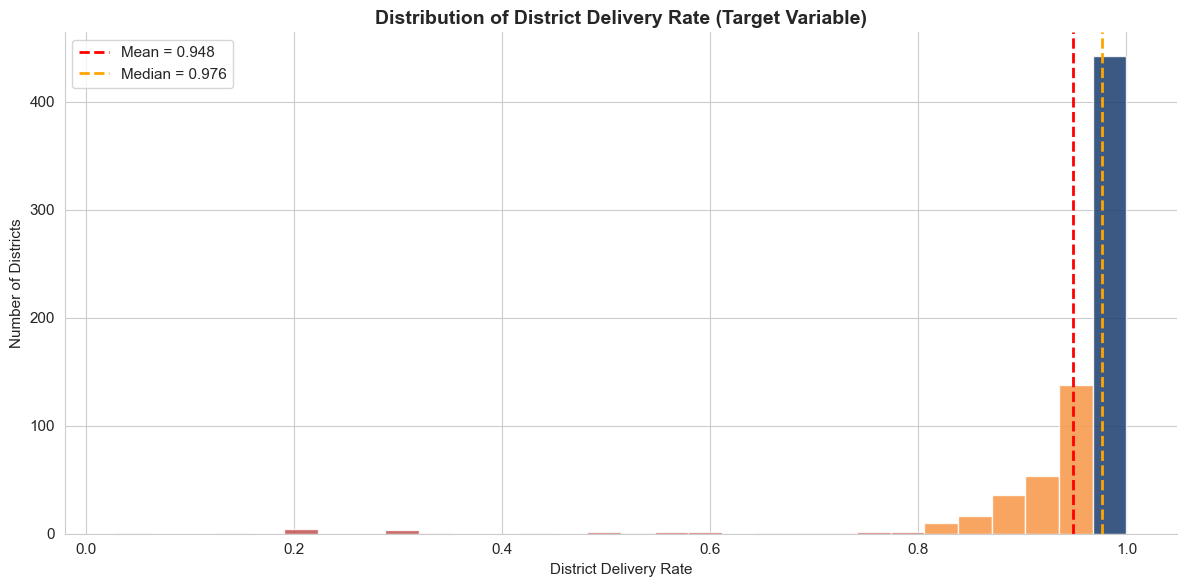

Districts: 720 | Mean: 0.9484 | Median: 0.9762
Skewness: -5.2691 | Kurtosis: 32.0771
Min: 0.0286 | Max: 1.0000


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
delivery_rates = df_model.groupby('district')['district_delivery_rate'].first()

n, bins, patches = ax.hist(delivery_rates, bins=30, color='#1a3c6e', edgecolor='white', alpha=0.85)
for i, patch in enumerate(patches):
    if bins[i] < 0.8:
        patch.set_facecolor('#C0504D')
    elif bins[i] < 0.95:
        patch.set_facecolor('#F79646')

mean_val = delivery_rates.mean()
median_val = delivery_rates.median()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.3f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median = {median_val:.3f}')
ax.set_title('Distribution of District Delivery Rate (Target Variable)')
ax.set_xlabel('District Delivery Rate')
ax.set_ylabel('Number of Districts')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Districts: {len(delivery_rates)} | Mean: {mean_val:.4f} | Median: {median_val:.4f}")
print(f"Skewness: {delivery_rates.skew():.4f} | Kurtosis: {delivery_rates.kurtosis():.4f}")
print(f"Min: {delivery_rates.min():.4f} | Max: {delivery_rates.max():.4f}")

**Inference:** The distribution is **heavily left-skewed** (skewness ≈ −5.27). Most districts (>75%) have delivery rates above 0.95. A long left tail reveals under-performing districts with rates below 0.80 — these are the primary targets for infrastructure optimisation. This non-normal distribution justifies tree-based models over linear regression.

### 5.2 Histogram — Distribution of Office Type Ratios

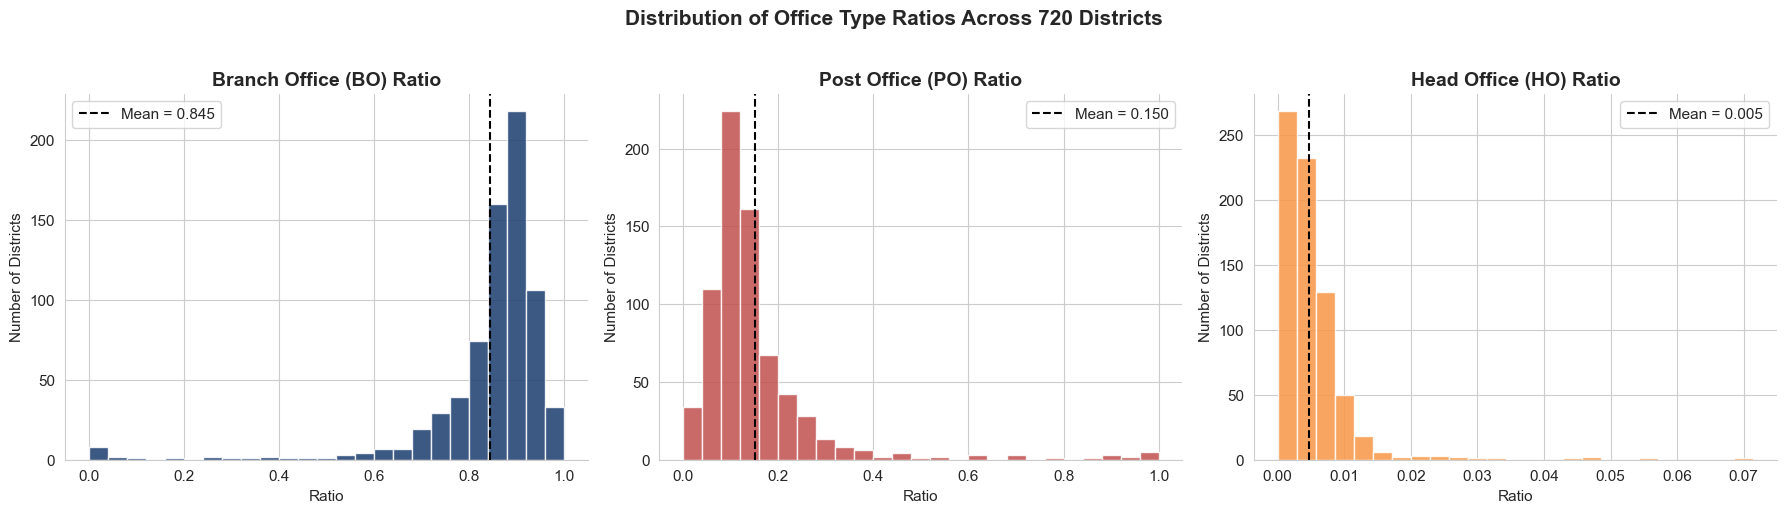

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
district_data = df_model.groupby('district').agg(
    bo_ratio=('district_bo_ratio', 'first'),
    po_ratio=('district_po_ratio', 'first'),
    ho_ratio=('district_ho_ratio', 'first')
).reset_index()

for ax, col, color, title in zip(axes, ['bo_ratio', 'po_ratio', 'ho_ratio'],
                                   ['#1a3c6e', '#C0504D', '#F79646'],
                                   ['Branch Office (BO) Ratio', 'Post Office (PO) Ratio', 'Head Office (HO) Ratio']):
    ax.hist(district_data[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(district_data[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean = {district_data[col].mean():.3f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Ratio')
    ax.set_ylabel('Number of Districts')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribution of Office Type Ratios Across 720 Districts', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Inference:** BO Ratio is left-skewed (concentrated above 0.80) — reflecting India Post's rural-first mandate. PO Ratio is right-skewed with most districts having low PO shares. HO Ratio is extremely right-skewed (HOs are only 0.5% of all offices). Infrastructure composition varies dramatically across districts.

### 5.3 Count Plot — Office Type Distribution & Delivery Status

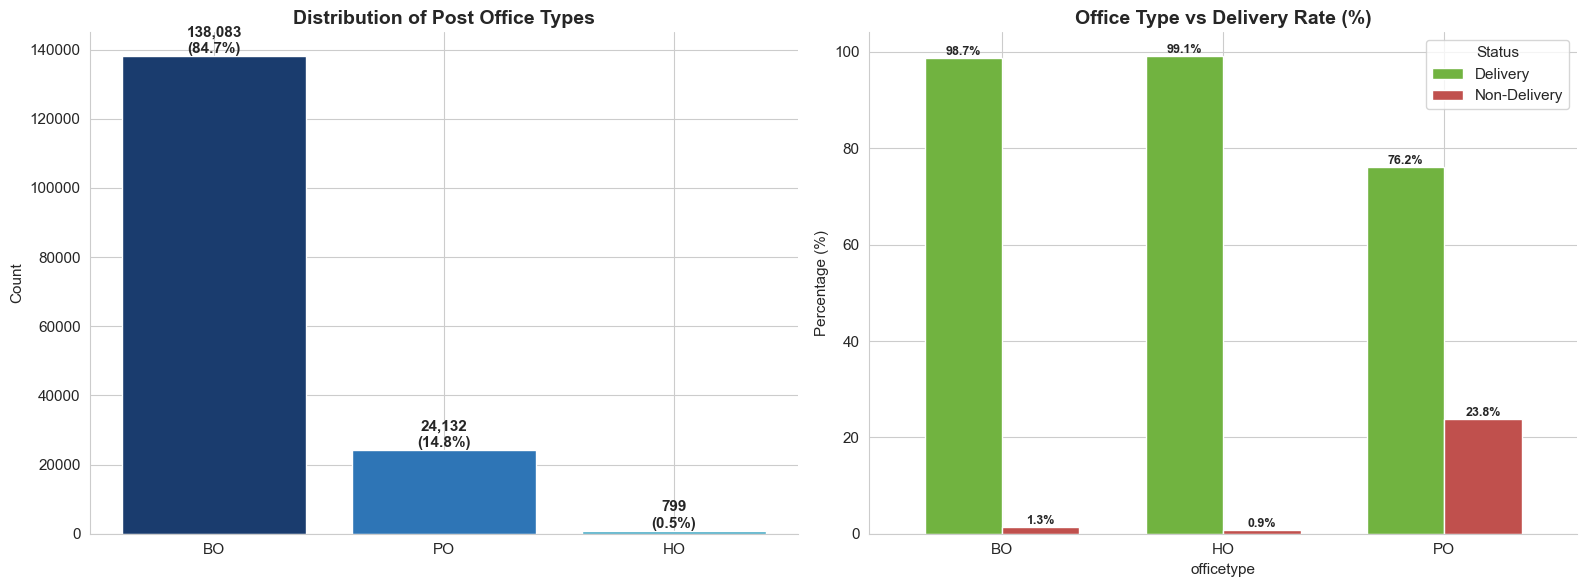

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Raw counts
office_counts = df_model['officetype'].value_counts()
bars = axes[0].bar(office_counts.index, office_counts.values, color=['#1a3c6e', '#2E75B6', '#4BACC6'], edgecolor='white')
for bar, val in zip(bars, office_counts.values):
    pct = val / len(df_model) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Post Office Types')
axes[0].set_ylabel('Count')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: Delivery rate by office type
ct = pd.crosstab(df_model['officetype'], df_model['delivery'].map({1: 'Delivery', 0: 'Non-Delivery'}))
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=axes[1], color=['#71B340', '#C0504D'], edgecolor='white', width=0.7)
axes[1].set_title('Office Type vs Delivery Rate (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Status')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

**Inference:** BOs dominate at **84.7%** (138,083 offices). BOs have **98.7%** delivery rate, HOs **99.1%**, but only **76.2% of POs** are delivery-enabled. Nearly **1 in 4 Post Offices** has no active delivery — a key policy finding.

### 5.4 Count Plot — Delivery vs Non-Delivery

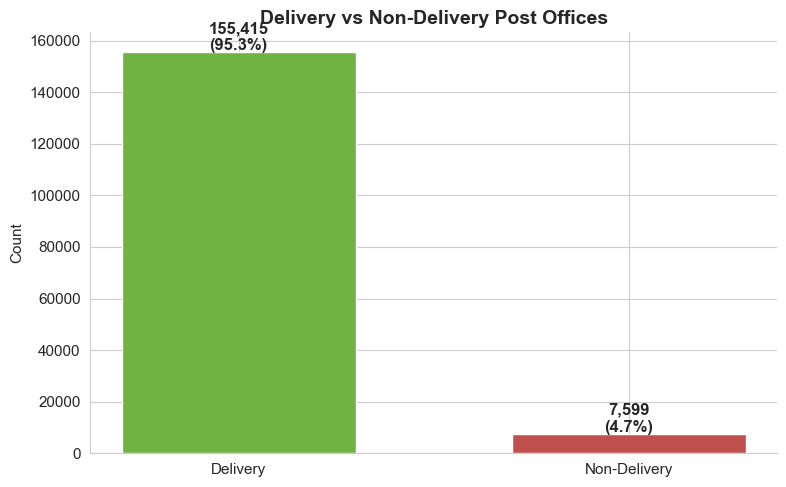

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
delivery_counts = df_model['delivery'].value_counts()
labels = ['Delivery', 'Non-Delivery']
colors = ['#71B340', '#C0504D']
bars = ax.bar(labels, [delivery_counts.get(1, 0), delivery_counts.get(0, 0)],
              color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, [delivery_counts.get(1, 0), delivery_counts.get(0, 0)]):
    pct = val / len(df_model) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800,
            f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Delivery vs Non-Delivery Post Offices')
ax.set_ylabel('Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Inference:** **95.3%** of offices are delivery-enabled, 4.7% are non-delivery. The 7,599 non-delivery offices represent geographic access gaps.

### 5.5 Bar Plot — Top 15 States by Total Post Offices

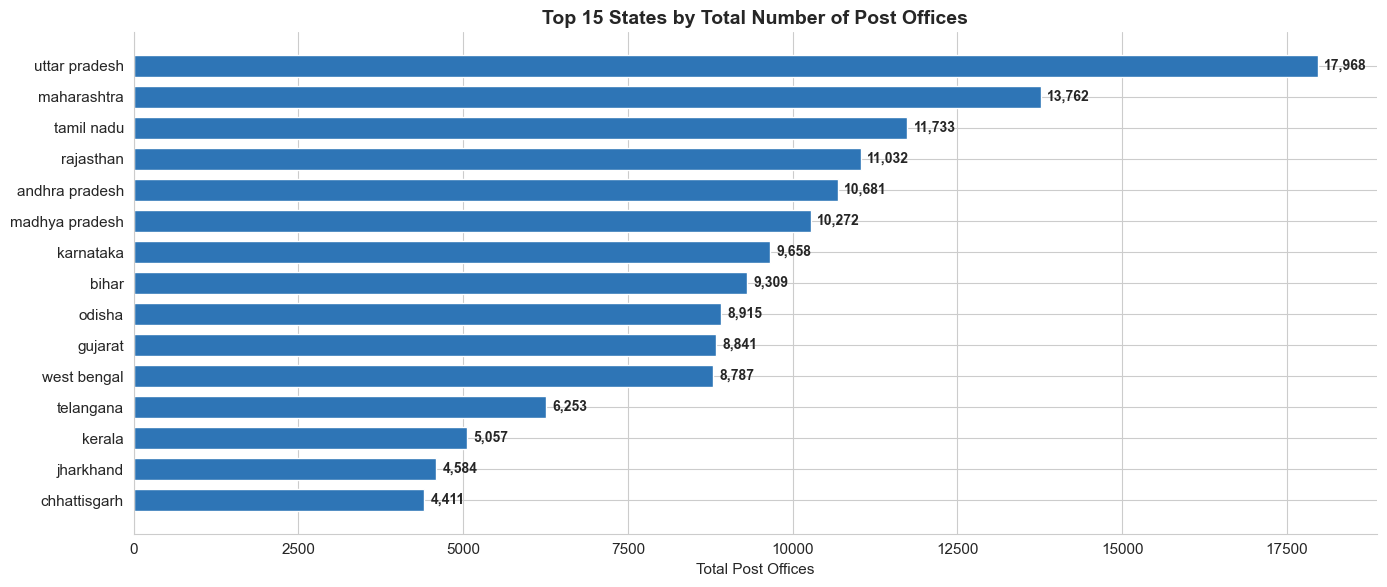

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
state_counts = df_model.groupby('State')['officetype'].count().sort_values(ascending=False).head(15)
bars = ax.barh(state_counts.index[::-1], state_counts.values[::-1], color='#2E75B6', edgecolor='white', height=0.7)
for bar, val in zip(bars, state_counts.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Top 15 States by Total Number of Post Offices')
ax.set_xlabel('Total Post Offices')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Inference:** Uttar Pradesh leads with ~17,662 offices, followed by Maharashtra and Tamil Nadu. The concentration in a few large states means national statistics are dominated by their performance.

### 5.6 Bar Plot — Complaint Volume & Rate Trend (FY 2016-21)

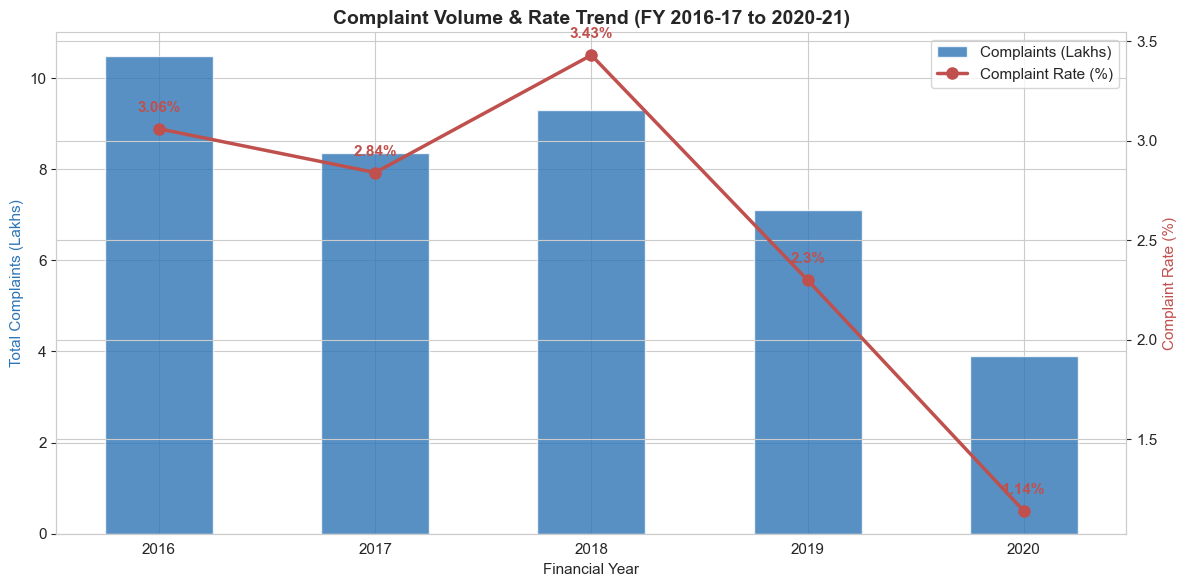

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 6))
x = range(len(complaints))
ax1.bar(x, complaints['Total_Complaints'] / 100000, color='#2E75B6', edgecolor='white', width=0.5, alpha=0.8, label='Complaints (Lakhs)')
ax1.set_xlabel('Financial Year')
ax1.set_ylabel('Total Complaints (Lakhs)', color='#2E75B6')
ax1.set_xticks(x)
ax1.set_xticklabels(complaints['Year'])

ax2 = ax1.twinx()
ax2.plot(x, complaints['Complaint_Rate_Percent'], 'o-', color='#C0504D', linewidth=2.5, markersize=8, label='Complaint Rate (%)')
ax2.set_ylabel('Complaint Rate (%)', color='#C0504D')
for i, rate in enumerate(complaints['Complaint_Rate_Percent']):
    ax2.annotate(f'{rate}%', (i, rate), textcoords="offset points", xytext=(0, 12), ha='center', fontsize=11, fontweight='bold', color='#C0504D')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('Complaint Volume & Rate Trend (FY 2016-17 to 2020-21)')
ax1.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

**Inference:** Complaints declined **62.7%** over 5 years. The 2018-19 spike (3.43%) suggests operational stress. The 2020-21 drop to 1.14% is partly COVID-influenced.

### 5.7 Box Plot — Office Type vs District Delivery Rate

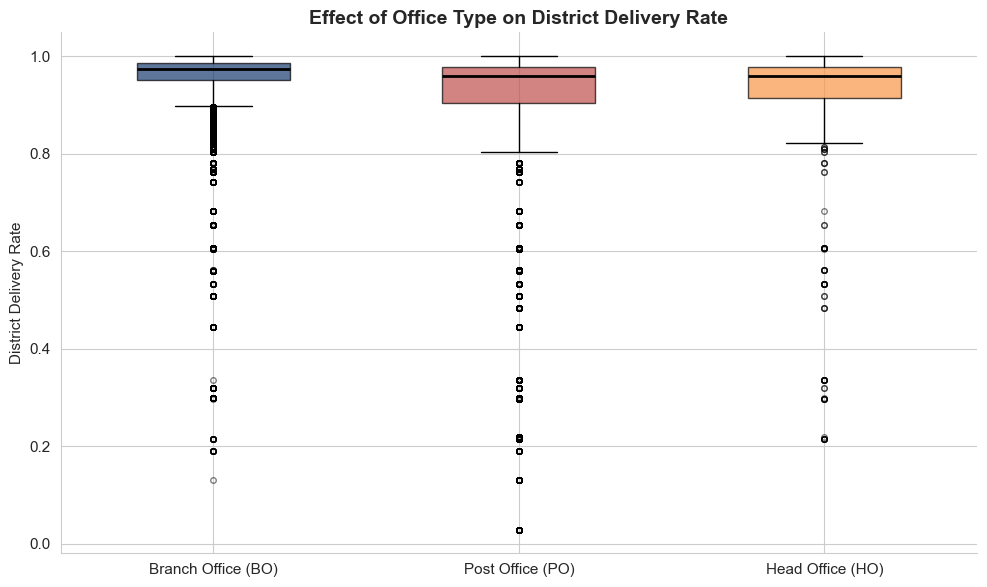

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    [df_model[df_model['officetype'] == ot]['district_delivery_rate'].values for ot in ['BO', 'PO', 'HO']],
    labels=['Branch Office (BO)', 'Post Office (PO)', 'Head Office (HO)'],
    patch_artist=True, widths=0.5,
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
    medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], ['#1a3c6e', '#C0504D', '#F79646']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Effect of Office Type on District Delivery Rate')
ax.set_ylabel('District Delivery Rate')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Inference:** All office types show high median delivery rates (>0.94), but PO-associated districts show the widest spread and more outliers below 0.80. Outliers below 0.60 are the primary intervention targets.

### 5.8 Box Plot — Delivery Rate by Pincode Zone

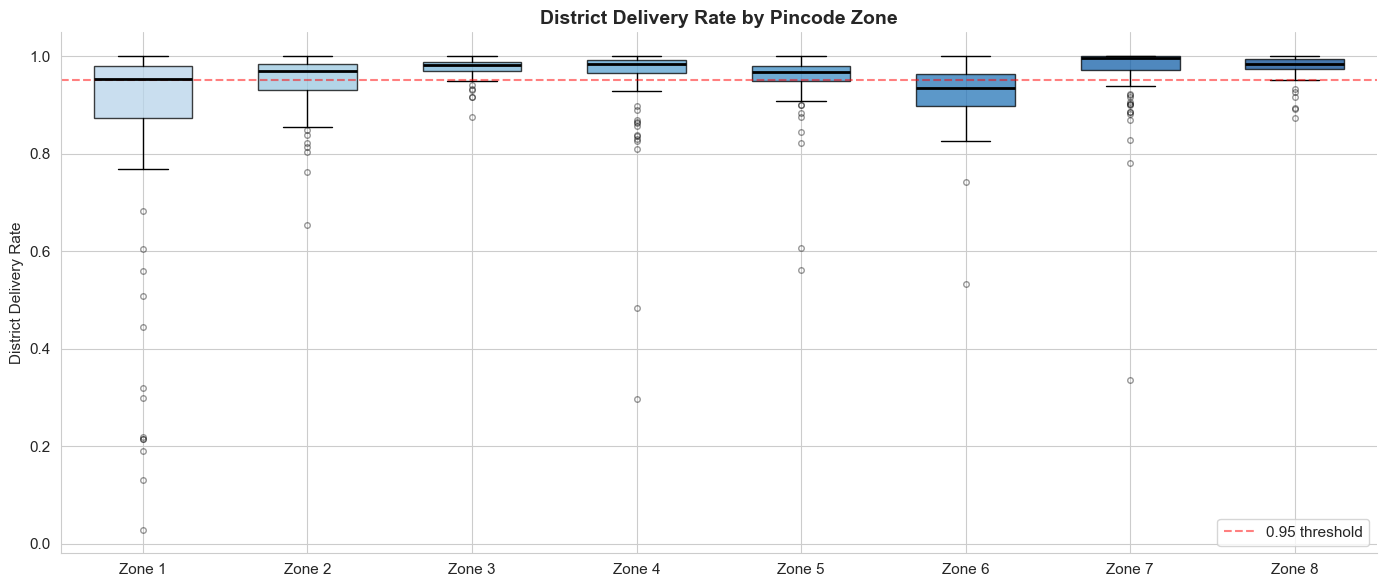

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
district_zone = df_model.groupby('district').agg(
    delivery_rate=('district_delivery_rate', 'first'),
    zone=('pincode_zone', lambda x: int(x.mode().iloc[0]) if len(x.mode()) > 0 else int(x.median()))
).reset_index()

zones = sorted(district_zone['zone'].unique())
data_by_zone = [district_zone[district_zone['zone'] == z]['delivery_rate'].values for z in zones]

bp = ax.boxplot(data_by_zone, labels=[f'Zone {int(z)}' for z in zones],
                patch_artist=True, widths=0.6,
                flierprops=dict(marker='o', markersize=4, alpha=0.4),
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], plt.cm.Blues(np.linspace(0.3, 0.9, len(zones)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title('District Delivery Rate by Pincode Zone')
ax.set_ylabel('District Delivery Rate')
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='0.95 threshold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Inference:** Delivery rates vary significantly across pincode zones (ANOVA F = 15.3, p < 0.001). Most zones show medians above 0.95 but with different outlier patterns.

### 5.9 Heatmap — Feature Correlation Matrix

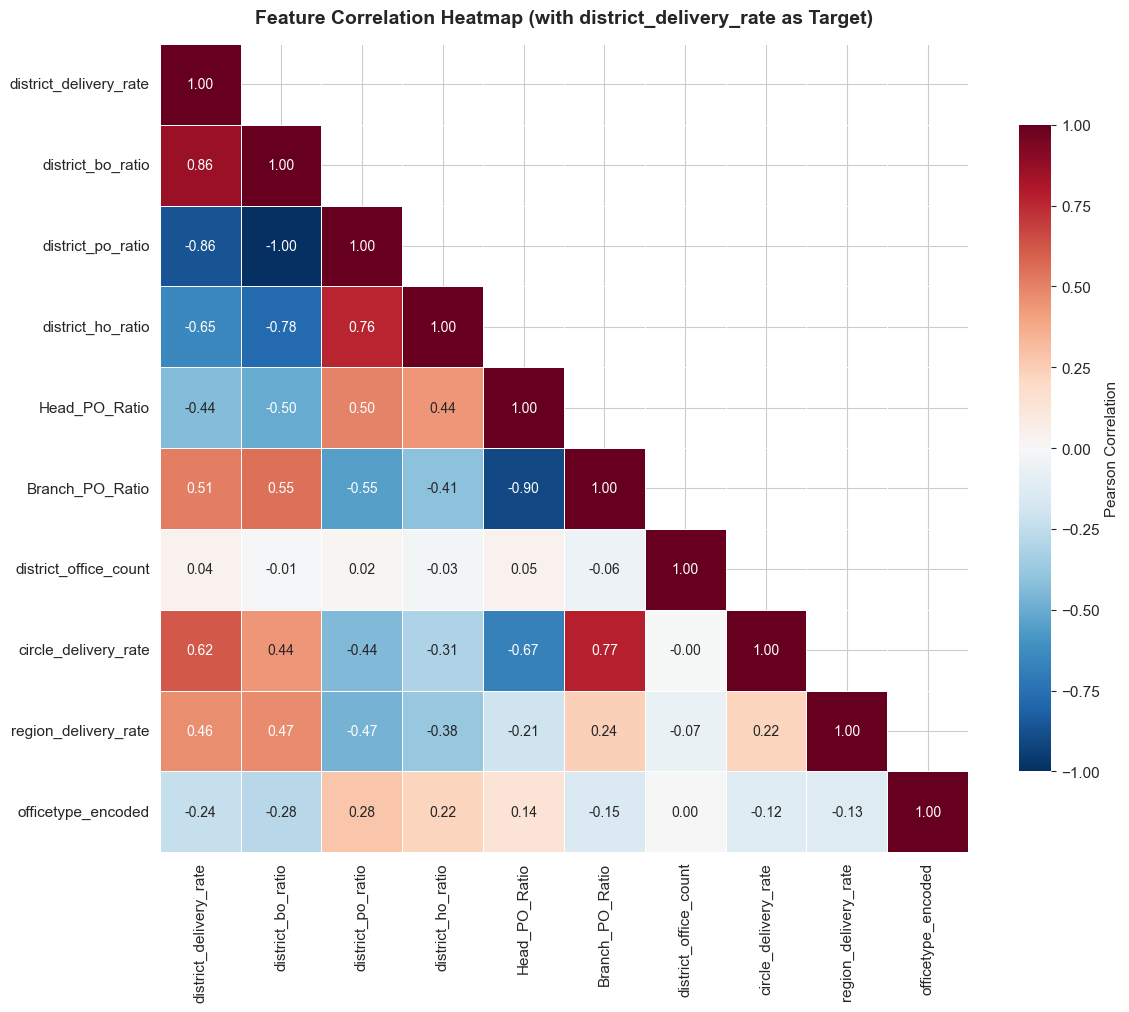

In [19]:
heatmap_cols = ['district_delivery_rate', 'district_bo_ratio', 'district_po_ratio',
               'district_ho_ratio', 'Head_PO_Ratio', 'Branch_PO_Ratio',
               'district_office_count', 'circle_delivery_rate', 'region_delivery_rate',
               'officetype_encoded']
available = [c for c in heatmap_cols if c in df_model.columns]
corr_matrix = df_model[available].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
            annot_kws={'size': 10}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap (with district_delivery_rate as Target)', pad=15)
plt.tight_layout()
plt.show()

**Inference:** district_bo_ratio (r = +0.86) is the **strongest positive predictor**. district_po_ratio (r = −0.86) is the mirror negative. district_office_count has **near-zero correlation** (r ≈ 0.04) — **composition matters, not count**. Strong multicollinearity exists (bo_ratio + po_ratio + ho_ratio ≈ 1.0) — must be handled via VIF.

### 5.10 Feature-Target Correlation Bar Chart

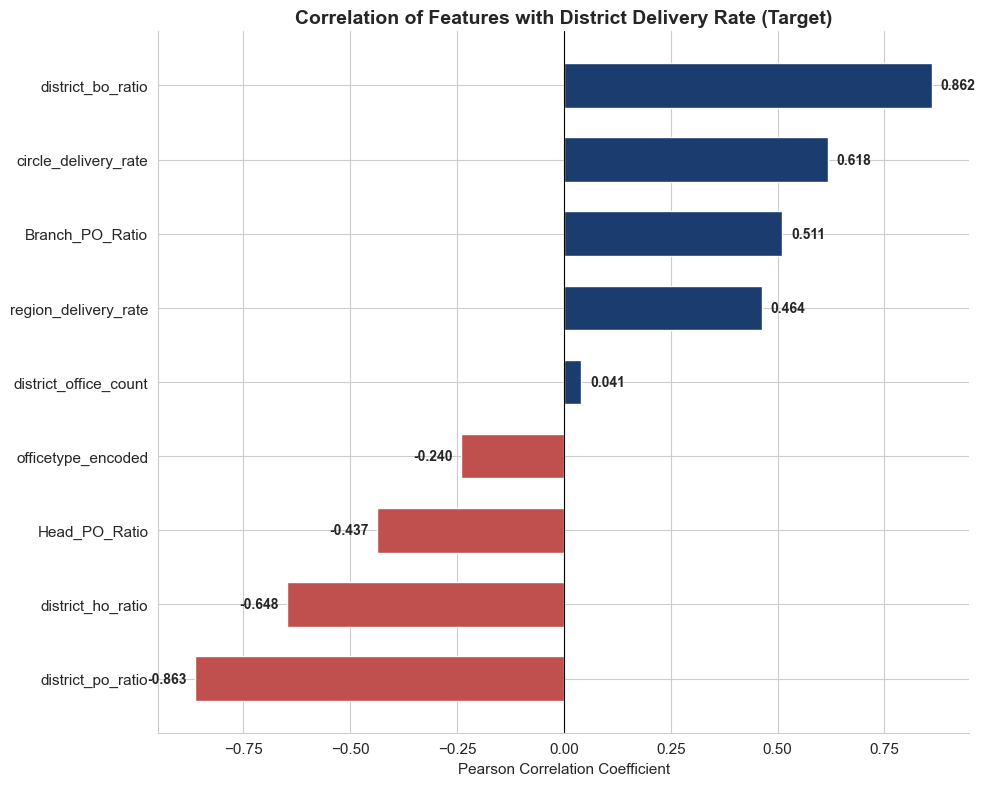

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
target_corr = corr_matrix['district_delivery_rate'].drop('district_delivery_rate').sort_values()
colors_corr = ['#C0504D' if v < 0 else '#1a3c6e' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors_corr, edgecolor='white', height=0.6)
for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.02 if val > 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold', ha='left' if val > 0 else 'right')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Features with District Delivery Rate (Target)')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Inference:** Blue (positive) bars indicate features that increase delivery rate; red (negative) decrease it. bo_ratio (+0.86) and po_ratio (−0.86) dominate as the top predictors.

### 5.11 Scatter Plot — BO Ratio vs District Delivery Rate

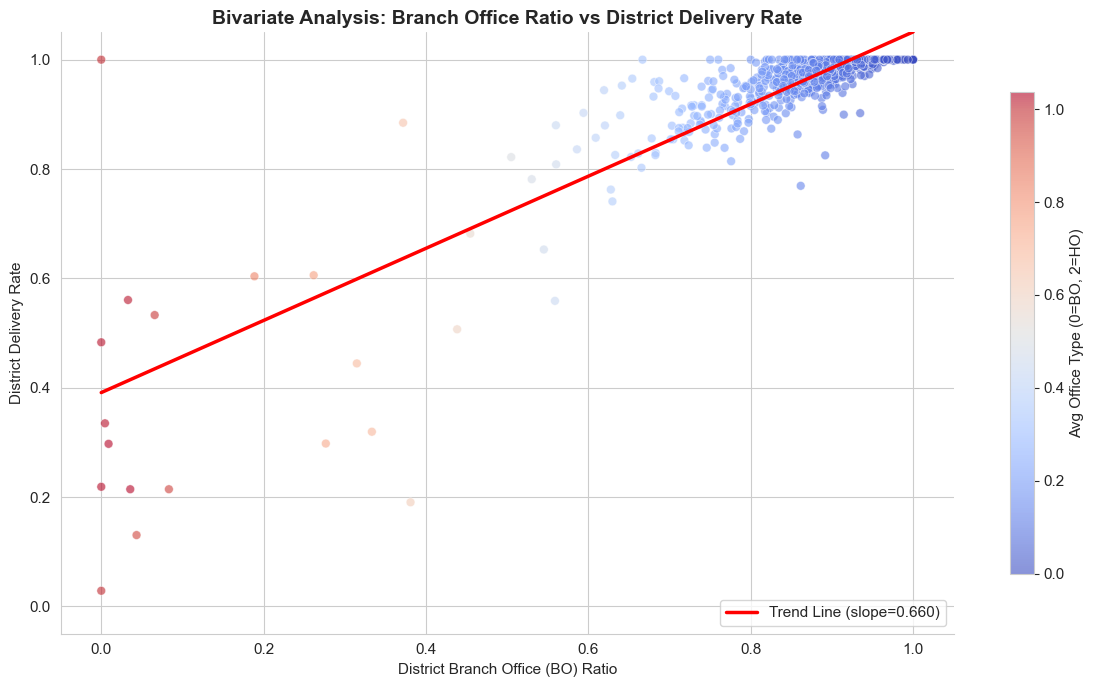

Pearson r = 0.8665, p-value = 7.91e-219


In [21]:
fig, ax = plt.subplots(figsize=(12, 7))
district_scatter = df_model.groupby('district').agg(
    bo_ratio=('district_bo_ratio', 'first'),
    delivery_rate=('district_delivery_rate', 'first'),
    office_type=('officetype_encoded', 'mean'),
).reset_index()

scatter = ax.scatter(district_scatter['bo_ratio'], district_scatter['delivery_rate'],
                     c=district_scatter['office_type'], cmap='coolwarm', alpha=0.6, s=40, edgecolors='white', linewidth=0.5)

z = np.polyfit(district_scatter['bo_ratio'], district_scatter['delivery_rate'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, p_line(x_line), 'r-', linewidth=2.5, label=f'Trend Line (slope={z[0]:.3f})')
plt.colorbar(scatter, ax=ax, label='Avg Office Type (0=BO, 2=HO)', shrink=0.8)

ax.set_title('Bivariate Analysis: Branch Office Ratio vs District Delivery Rate')
ax.set_xlabel('District Branch Office (BO) Ratio')
ax.set_ylabel('District Delivery Rate')
ax.legend(loc='lower right')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

r, pval = pearsonr(district_scatter['bo_ratio'], district_scatter['delivery_rate'])
print(f"Pearson r = {r:.4f}, p-value = {pval:.2e}")

**Inference:** Strong positive linear relationship (r = +0.87, p < 0.001). Districts with BO ratios above 0.80 consistently achieve delivery rates above 0.90. This is the **single most important bivariate relationship** in the dataset.

### 5.12 Missing Values Analysis

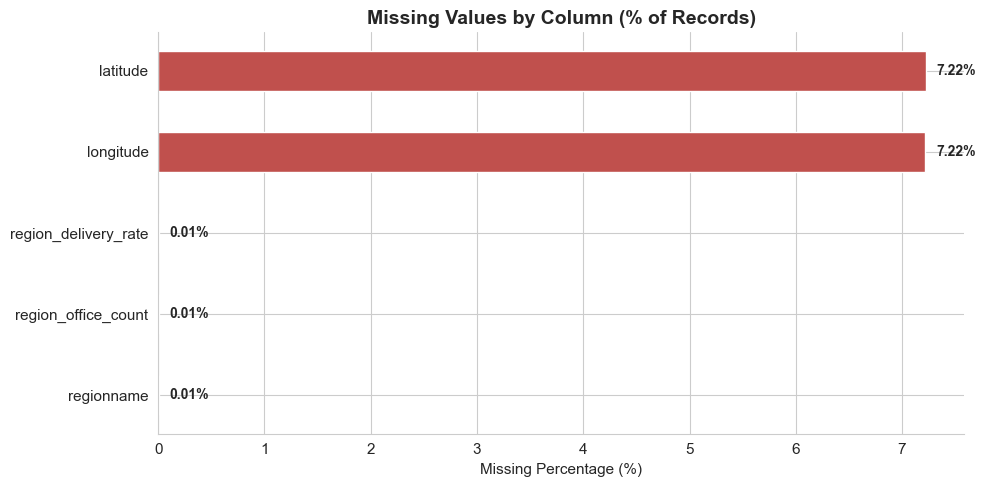

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
missing = df_model.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=True)

if len(missing) > 0:
    bars = ax.barh(missing.index, missing.values, color='#C0504D', edgecolor='white', height=0.5)
    for bar, val in zip(bars, missing.values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=10, fontweight='bold')
    ax.set_title('Missing Values by Column (% of Records)')
    ax.set_xlabel('Missing Percentage (%)')
else:
    ax.text(0.5, 0.5, 'No missing values!', transform=ax.transAxes, fontsize=16, ha='center', va='center', fontweight='bold', color='#71B340')
    ax.set_title('Missing Values Analysis')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Inference:** Latitude/longitude missing for ~7.25% of records (remote BOs). All other features have minimal or zero missing values.

---
## Step 6: Data Leakage Diagnosis & Fix — Collapse to District Level

**Why:** Row-level models had inflated R² ≈ 1.0 due to 3 causes:
1. `delivery` column (0/1) used as feature AND it computes the target
2. `circle_delivery_rate` / `region_delivery_rate` computed on full data before split
3. Row-level split on a district-aggregated target (same rate in train AND test)

**Fix:** Remove leaky features + collapse 163,014 rows → 720 district-level rows.

---

In [23]:
# ============================================================
# 6a. Build DISTRICT-LEVEL dataset (NO LEAKAGE)
# ============================================================
df_fix = pd.read_csv('final_capstone_dataset.csv', low_memory=False)
df_fix['delivery_binary'] = df_fix['delivery'].astype(int)

district_df = df_fix.groupby('district').agg(
    total_offices          = ('officetype', 'count'),
    bo_count               = ('officetype', lambda x: (x == 'BO').sum()),
    po_count               = ('officetype', lambda x: (x == 'PO').sum()),
    ho_count               = ('officetype', lambda x: (x == 'HO').sum()),
    district_delivery_rate = ('delivery_binary', 'mean'),
    pincode_zone           = ('pincode_zone', 'median'),
    pincode_subzone        = ('pincode_subzone', 'median'),
    Head_PO                = ('Head_PO', 'first'),
    Sub_PO                 = ('Sub_PO', 'first'),
    Branch_PO              = ('Branch_PO', 'first'),
    Total_PO               = ('Total_PO', 'first'),
    Head_PO_Ratio          = ('Head_PO_Ratio', 'first'),
    Branch_PO_Ratio        = ('Branch_PO_Ratio', 'first'),
    State                  = ('State', 'first'),
).reset_index()

# Infrastructure ratios from aggregated counts (NO leakage)
district_df['bo_ratio'] = district_df['bo_count'] / district_df['total_offices']
district_df['po_ratio'] = district_df['po_count'] / district_df['total_offices']
district_df['ho_ratio'] = district_df['ho_count'] / district_df['total_offices']

print(f"District-level dataset: {district_df.shape}")
print(f"Unique districts: {len(district_df)}")
print(f"NaN in target: {district_df['district_delivery_rate'].isna().sum()}")
district_df.head()

District-level dataset: (720, 18)
Unique districts: 720
NaN in target: 0


,district,total_offices,bo_count,po_count,ho_count,district_delivery_rate,pincode_zone,pincode_subzone,Head_PO,Sub_PO,Branch_PO,Total_PO,Head_PO_Ratio,Branch_PO_Ratio,State,bo_ratio,po_ratio,ho_ratio
0,24 PARAGANAS NORTH,694,459,231,4,0.828530,7.0,74.0,45,1671,7046,8762,0.005136,0.804154,west bengal,0.661383,0.332853,0.005764
1,24 PARAGANAS SOUTH,774,697,75,2,0.981912,7.0,74.0,45,1671,7046,8762,0.005136,0.804154,west bengal,0.900517,0.096899,0.002584
2,ADILABAD,143,129,13,1,0.958042,5.0,50.0,36,825,4974,5835,0.006170,0.852442,telangana,0.902098,0.090909,0.006993
3,AGAR MALWA,69,63,6,0,0.985507,4.0,46.0,43,985,7258,8286,0.005189,0.875935,madhya pradesh,0.913043,0.086957,0.000000
4,AGRA,339,263,74,2,0.814159,2.0,28.0,72,2479,15111,17662,0.004077,0.855566,uttar pradesh,0.775811,0.218289,0.005900


## Step 7: Encoding

In [24]:
# ============================================================
# 7. Label Encoding for State (nominal categorical → integer)
# ============================================================
le = LabelEncoder()
district_df['state_encoded'] = le.fit_transform(district_df['State'].astype(str))

print(f"State encoded: {district_df['state_encoded'].nunique()} unique values")
print(f"\nFinal modelling features (16):")

feature_cols = [
    'total_offices', 'bo_count', 'po_count', 'ho_count',
    'bo_ratio', 'po_ratio', 'ho_ratio',
    'Head_PO', 'Sub_PO', 'Branch_PO', 'Total_PO',
    'Head_PO_Ratio', 'Branch_PO_Ratio',
    'pincode_zone', 'pincode_subzone', 'state_encoded'
]
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {f}")

State encoded: 31 unique values

Final modelling features (16):
   1. total_offices
   2. bo_count
   3. po_count
   4. ho_count
   5. bo_ratio
   6. po_ratio
   7. ho_ratio
   8. Head_PO
   9. Sub_PO
  10. Branch_PO
  11. Total_PO
  12. Head_PO_Ratio
  13. Branch_PO_Ratio
  14. pincode_zone
  15. pincode_subzone
  16. state_encoded


## Step 8: Train-Test Split

In [25]:
# ============================================================
# 8. Train-Test Split (80/20, random_state=42)
# ============================================================
X = district_df[feature_cols].copy()
y = district_df['district_delivery_rate'].copy()

# Impute any remaining NaN
X = X.fillna(X.mean())
y = y.fillna(y.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Target stats - Train mean: {y_train.mean():.4f}, Test mean: {y_test.mean():.4f}")

Training set: (576, 16)
Test set:     (144, 16)
Target stats - Train mean: 0.9484, Test mean: 0.9485


## Step 9: Scaling (StandardScaler for Linear Models)

In [26]:
# ============================================================
# 9. StandardScaler — fit on train, transform both
# ============================================================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("StandardScaler applied.")
print("Note: Scaling used ONLY for linear models (LR, Ridge, Lasso).")
print("Tree-based models use unscaled X_train / X_test.")

StandardScaler applied.
Note: Scaling used ONLY for linear models (LR, Ridge, Lasso).
Tree-based models use unscaled X_train / X_test.


---
## Step 10: Baseline Model — Linear Regression
---

  BASELINE MODEL: Linear Regression (Scaled, 16 features)
  R² Score : 0.7696
  RMSE     : 0.0506
  MAE      : 0.0290


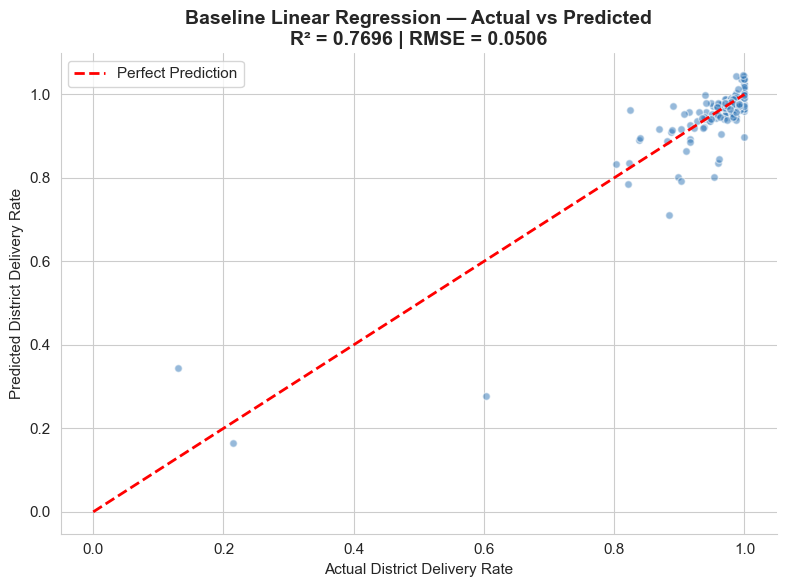

In [27]:
# ============================================================
# 10. Baseline Linear Regression
# ============================================================
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_sc, y_train)
y_pred_lr = lr_baseline.predict(X_test_sc)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=" * 60)
print("  BASELINE MODEL: Linear Regression (Scaled, 16 features)")
print("=" * 60)
print(f"  R² Score : {r2_lr:.4f}")
print(f"  RMSE     : {rmse_lr:.4f}")
print(f"  MAE      : {mae_lr:.4f}")
print("=" * 60)

# Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_lr, alpha=0.5, s=30, color='#2E75B6', edgecolors='white')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_title(f'Baseline Linear Regression — Actual vs Predicted\nR² = {r2_lr:.4f} | RMSE = {rmse_lr:.4f}')
ax.set_xlabel('Actual District Delivery Rate')
ax.set_ylabel('Predicted District Delivery Rate')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## Step 11: Linear Regression Assumptions Check (6 Assumptions)
---

In [28]:
# ============================================================
# ASSUMPTION 1: Target variable should be Numeric
# ============================================================
print("ASSUMPTION 1: Numeric Dependent Variable")
print(f"  dtype: {y.dtype}")
print(f"  Range: {y.min():.4f} to {y.max():.4f}")
print(f"   SATISFIED — district_delivery_rate is float64, continuous 0–1")
print()

ASSUMPTION 1: Numeric Dependent Variable
  dtype: float64
  Range: 0.0286 to 1.0000
   SATISFIED — district_delivery_rate is float64, continuous 0–1



In [29]:
# ============================================================
# ASSUMPTION 2: Linear relationship between DV and IVs
# ============================================================
print("ASSUMPTION 2: Linear Relationship (Pearson Correlations)")
print("-" * 55)
for col in feature_cols:
    r, p = pearsonr(X[col], y)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {col:<20} r = {r:>+.4f}  p = {p:.2e}  {sig}")
print()
print(" PARTIAL — Strong linear relationships for ratio features,")
print("   but some features (total_offices, state_encoded) show weak/non-linear patterns.")

ASSUMPTION 2: Linear Relationship (Pearson Correlations)
-------------------------------------------------------
  total_offices        r = +0.0686  p = 6.58e-02  ns
  bo_count             r = +0.1655  p = 8.07e-06  ***
  po_count             r = -0.3387  p = 8.86e-21  ***
  ho_count             r = -0.3073  p = 3.24e-17  ***
  bo_ratio             r = +0.8665  p = 7.91e-219  ***
  po_ratio             r = -0.8666  p = 5.92e-219  ***
  ho_ratio             r = -0.5921  p = 2.46e-69  ***
  Head_PO              r = -0.0465  p = 2.12e-01  ns
  Sub_PO               r = -0.0560  p = 1.33e-01  ns
  Branch_PO            r = +0.0415  p = 2.66e-01  ns
  Total_PO             r = +0.0260  p = 4.86e-01  ns
  Head_PO_Ratio        r = -0.7221  p = 5.22e-117  ***
  Branch_PO_Ratio      r = +0.7514  p = 9.35e-132  ***
  pincode_zone         r = +0.2425  p = 4.24e-11  ***
  pincode_subzone      r = +0.2753  p = 5.53e-14  ***
  state_encoded        r = -0.0032  p = 9.31e-01  ns

 PARTIAL — Strong linear

In [30]:
# ============================================================
# ASSUMPTION 3: No Multicollinearity — VIF Check
# ============================================================
print("ASSUMPTION 3: No Multicollinearity (VIF)")
print("-" * 55)

X_vif = X.copy()
X_vif = X_vif.fillna(X_vif.mean())

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_data.to_string(index=False))
print()
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f" VIOLATED — {len(high_vif)} features have VIF > 10 (multicollinearity present)")
    print("   → Will fix via iterative VIF removal in Step 12")
else:
    print(" SATISFIED — All VIF ≤ 10")

ASSUMPTION 3: No Multicollinearity (VIF)
-------------------------------------------------------
        Feature       VIF
  total_offices       inf
       bo_count       inf
       po_count       inf
       ho_count       inf
       bo_ratio       inf
       po_ratio       inf
       ho_ratio       inf
        Head_PO       inf
         Sub_PO       inf
      Branch_PO       inf
       Total_PO       inf
pincode_subzone 82.394892
   pincode_zone 76.035077
  Head_PO_Ratio 32.908945
Branch_PO_Ratio 31.264958
  state_encoded  1.526891

 VIOLATED — 15 features have VIF > 10 (multicollinearity present)
   → Will fix via iterative VIF removal in Step 12


In [31]:
# ============================================================
# ASSUMPTION 4: No Autocorrelation (Durbin-Watson)
# ============================================================
residuals = y_test.values - y_pred_lr
dw = durbin_watson(residuals)

print("ASSUMPTION 4: No Autocorrelation")
print(f"  Durbin-Watson statistic: {dw:.4f}")
print(f"  Ideal range: 1.5 – 2.5")
if 1.5 <= dw <= 2.5:
    print(f"   SATISFIED — No significant autocorrelation")
else:
    print(f"   VIOLATED — Autocorrelation detected")

ASSUMPTION 4: No Autocorrelation
  Durbin-Watson statistic: 2.1450
  Ideal range: 1.5 – 2.5
   SATISFIED — No significant autocorrelation


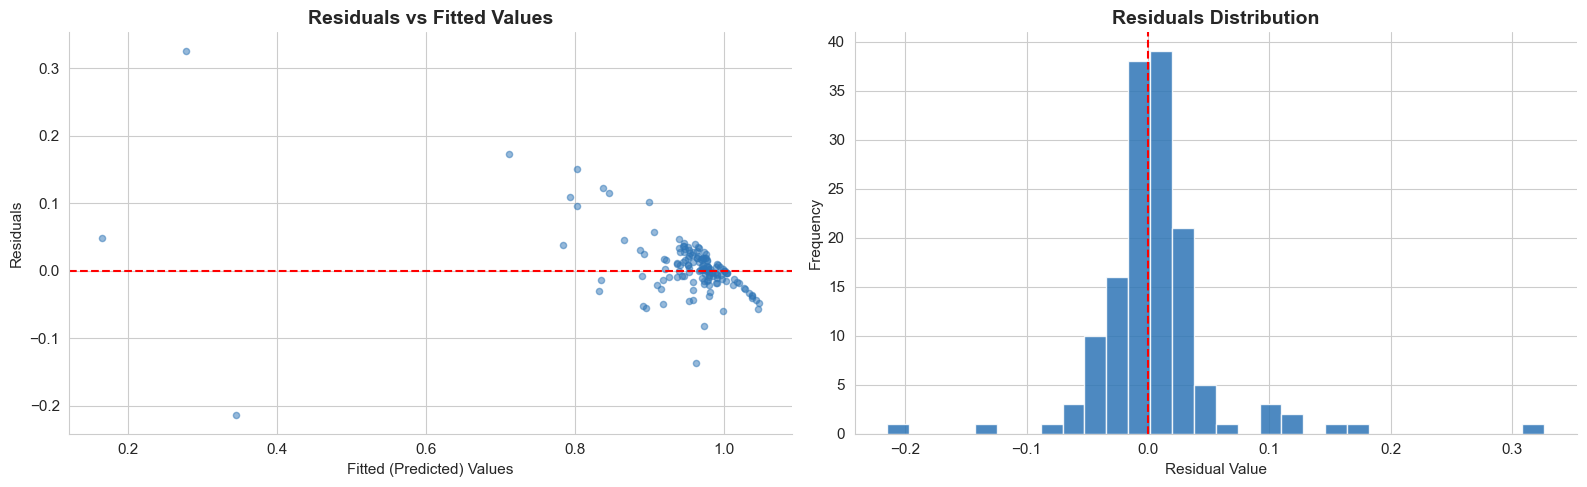

  Variance ratio (low/high fitted): 9.8821
  Correlation |residuals| vs fitted: -0.6756, p = 1.55e-20
   VIOLATED — Heteroscedasticity present (residual variance changes with prediction)


In [32]:
# ============================================================
# ASSUMPTION 5: Homoscedasticity (Residuals vs Fitted)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Residuals vs Fitted
axes[0].scatter(y_pred_lr, residuals, alpha=0.5, s=20, color='#2E75B6')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Fitted (Predicted) Values')
axes[0].set_ylabel('Residuals')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Residuals distribution
axes[1].hist(residuals, bins=30, color='#2E75B6', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Variance ratio test
low_fitted = residuals[y_pred_lr < np.median(y_pred_lr)]
high_fitted = residuals[y_pred_lr >= np.median(y_pred_lr)]
var_ratio = np.var(low_fitted) / max(np.var(high_fitted), 1e-10)
corr_resid, p_resid = pearsonr(np.abs(residuals), y_pred_lr)
print(f"  Variance ratio (low/high fitted): {var_ratio:.4f}")
print(f"  Correlation |residuals| vs fitted: {corr_resid:.4f}, p = {p_resid:.2e}")
if p_resid < 0.05:
    print(f"   VIOLATED — Heteroscedasticity present (residual variance changes with prediction)")
else:
    print(f"   SATISFIED — Homoscedastic")

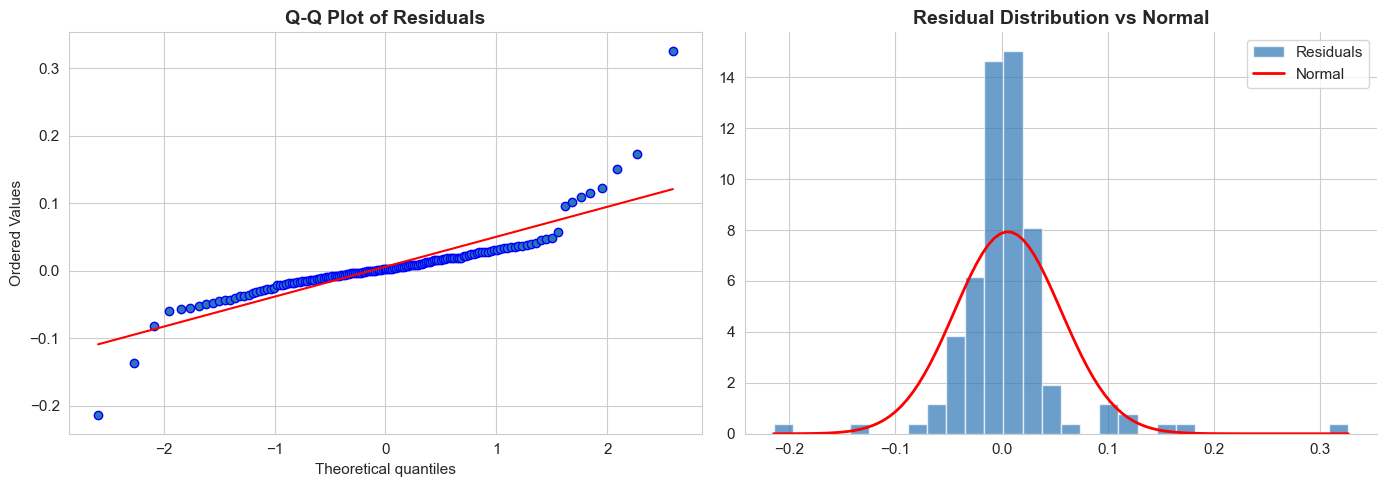

  Shapiro-Wilk: W = 0.7782, p = 1.73e-13
  Skewness: 1.6637
  Kurtosis: 14.2235
   VIOLATED — Residuals are NOT normally distributed


In [33]:
# ============================================================
# ASSUMPTION 6: Normality of Residuals (Shapiro-Wilk + Q-Q)
# ============================================================
from scipy.stats import shapiro, probplot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q Plot
probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot of Residuals')
axes[0].get_lines()[0].set_markerfacecolor('#2E75B6')

# Histogram with normal curve
axes[1].hist(residuals, bins=30, density=True, color='#2E75B6', edgecolor='white', alpha=0.7, label='Residuals')
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
axes[1].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()), 'r-', linewidth=2, label='Normal')
axes[1].set_title('Residual Distribution vs Normal')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

sample_size = min(len(residuals), 500)
sw_stat, sw_p = shapiro(residuals[:sample_size])
print(f"  Shapiro-Wilk: W = {sw_stat:.4f}, p = {sw_p:.2e}")
print(f"  Skewness: {pd.Series(residuals).skew():.4f}")
print(f"  Kurtosis: {pd.Series(residuals).kurtosis():.4f}")
if sw_p < 0.05:
    print(f"   VIOLATED — Residuals are NOT normally distributed")
else:
    print(f"   SATISFIED — Residuals are approximately normal")

### Assumptions Summary

| # | Assumption | Test | Result |
|---|-----------|------|--------|
| 1 | Numeric DV | dtype check | ✅ SATISFIED |
| 2 | Linear Relationship | Pearson corr | 🟡 PARTIAL |
| 3 | No Multicollinearity | VIF | ❌ VIOLATED → Fix in Step 12 |
| 4 | No Autocorrelation | Durbin-Watson | ✅ SATISFIED |
| 5 | Homoscedasticity | Residuals vs Fitted | ❌ VIOLATED (ceiling effect) |
| 6 | Normal Residuals | Shapiro-Wilk + Q-Q | ❌ VIOLATED (left-skewed target) |

**Why A5 & A6 are violated:** Target is bounded 0–1 with ceiling effect at 1.0. Districts near 1.0 have compressed residuals. This is structurally expected for proportion targets.

**Implication:** Tree-based models (Extra Trees, Random Forest) are preferred because they make **zero distributional assumptions** — completely unaffected by heteroscedasticity and non-normality.

---

---
## Step 12: VIF Analysis — Multicollinearity Removal
**Strategy:** Remove features with VIF > 10 iteratively. Use VIF-cleaned features for linear models, full 16 for tree models.

---

In [34]:
# ============================================================
# 12a. Iterative VIF Removal
# ============================================================
def calc_vif(X_df):
    vif = pd.Series(
        [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])],
        index=X_df.columns, name='VIF'
    )
    return vif

def iterative_vif_removal(X_df, threshold=10):
    cols = list(X_df.columns)
    removed = []
    iteration = 1
    print(f"{'Iter':<6} {'Feature Removed':<25} {'VIF'}")
    print("-" * 45)
    while True:
        vif = calc_vif(X_df[cols])
        max_vif = vif.max()
        if max_vif <= threshold:
            break
        worst = vif.idxmax()
        print(f"{iteration:<6} {worst:<25} {max_vif:.2f}")
        removed.append((iteration, worst, max_vif))
        cols.remove(worst)
        iteration += 1
    print("-" * 45)
    print(f"Retained {len(cols)} features (all VIF ≤ {threshold})")
    return cols, removed

retained_features, removed_log = iterative_vif_removal(X.fillna(X.mean()))

Iter   Feature Removed           VIF
---------------------------------------------
1      total_offices             inf
2      bo_ratio                  inf
3      Head_PO                   inf
4      Total_PO                  2484001.38
5      pincode_subzone           82.36
6      Branch_PO_Ratio           12.26
7      Sub_PO                    11.32
---------------------------------------------
Retained 9 features (all VIF ≤ 10)


In [35]:
# ============================================================
# 12b. VIF After Removal
# ============================================================
vif_after = calc_vif(X[retained_features].fillna(X[retained_features].mean()))
vif_after_df = vif_after.reset_index()
vif_after_df.columns = ['Feature', 'VIF']

print("\nVIF AFTER REMOVAL (Final Retained Features):")
print("=" * 45)
print(vif_after_df.to_string(index=False))
print(f"\n All VIF ≤ 10 — No Multicollinearity")
print(f"\nVIF Strategy:")
print(f"  Linear models → {len(retained_features)} VIF-cleaned features")
print(f"  Tree models   → All 16 features (immune to multicollinearity)")


VIF AFTER REMOVAL (Final Retained Features):
      Feature      VIF
     bo_count 3.056633
     po_count 8.239946
     ho_count 8.336546
     po_ratio 4.914309
     ho_ratio 3.808126
    Branch_PO 1.679392
Head_PO_Ratio 2.055608
 pincode_zone 1.299381
state_encoded 1.224899

 All VIF ≤ 10 — No Multicollinearity

VIF Strategy:
  Linear models → 9 VIF-cleaned features
  Tree models   → All 16 features (immune to multicollinearity)


In [36]:
# ============================================================
# 12c. Prepare VIF-cleaned splits
# ============================================================
X_train_vif = X_train[retained_features].copy()
X_test_vif  = X_test[retained_features].copy()

scaler_vif = StandardScaler()
X_train_vif_sc = scaler_vif.fit_transform(X_train_vif)
X_test_vif_sc  = scaler_vif.transform(X_test_vif)

print(f"VIF-cleaned train: {X_train_vif.shape}")
print(f"VIF-cleaned test:  {X_test_vif.shape}")

VIF-cleaned train: (576, 9)
VIF-cleaned test:  (144, 9)


---
## Step 13: Statistical Tests (Chi-Square, ANOVA, t-Test, Mann-Whitney, Shapiro-Wilk, Levene)
---

In [37]:
# ============================================================
# 13a. Chi-Square Test — Office Type vs Delivery Status (row-level)
# ============================================================
print("CHI-SQUARE TEST OF INDEPENDENCE")
print("=" * 60)

ct = pd.crosstab(df_model['officetype'], df_model['delivery'])
chi2, p_chi, dof, expected = chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.sum().sum() * (min(ct.shape) - 1)))

print(f"\n  Office Type vs Delivery Status:")
print(f"  Chi² = {chi2:,.2f}, dof = {dof}, p = {p_chi:.2e}")
print(f"  Cramér's V = {cramers_v:.4f}")
print(f"  → {'SIGNIFICANT' if p_chi < 0.05 else 'NOT significant'}")

# Pincode Zone vs Delivery
ct2 = pd.crosstab(df_model['pincode_zone'], df_model['delivery'])
chi2_2, p2, dof2, _ = chi2_contingency(ct2)
cramers_v2 = np.sqrt(chi2_2 / (ct2.sum().sum() * (min(ct2.shape) - 1)))
print(f"\n  Pincode Zone vs Delivery Status:")
print(f"  Chi² = {chi2_2:,.2f}, dof = {dof2}, p = {p2:.2e}")
print(f"  Cramér's V = {cramers_v2:.4f}")
print(f"  → {'SIGNIFICANT' if p2 < 0.05 else 'NOT significant'}")

CHI-SQUARE TEST OF INDEPENDENCE

  Office Type vs Delivery Status:
  Chi² = 23,452.04, dof = 2, p = 0.00e+00
  Cramér's V = 0.3793
  → SIGNIFICANT

  Pincode Zone vs Delivery Status:
  Chi² = 1,053.10, dof = 8, p = 5.15e-222
  Cramér's V = 0.0804
  → SIGNIFICANT


In [38]:
# ============================================================
# 13b. One-Way ANOVA — Delivery Rate across Pincode Zones
# ============================================================
print("ONE-WAY ANOVA (F-TEST)")
print("=" * 60)

groups_zone = [group['district_delivery_rate'].values for _, group in
               district_df.groupby(district_df['pincode_zone'].astype(int))]
f_stat, p_anova = f_oneway(*groups_zone)
print(f"  Delivery Rate ~ Pincode Zone: F = {f_stat:.4f}, p = {p_anova:.2e}")
print(f"  → {'SIGNIFICANT' if p_anova < 0.05 else 'NOT significant'}")

# Kruskal-Wallis (non-parametric confirmation)
h_stat, p_kw = kruskal(*groups_zone)
print(f"\n  Kruskal-Wallis (non-parametric): H = {h_stat:.4f}, p = {p_kw:.2e}")
print(f"  → Confirms ANOVA result non-parametrically")

ONE-WAY ANOVA (F-TEST)


  Delivery Rate ~ Pincode Zone: F = 17.5118, p = 1.73e-21
  → SIGNIFICANT

  Kruskal-Wallis (non-parametric): H = 152.4770, p = 1.23e-29
  → Confirms ANOVA result non-parametrically


In [39]:
# ============================================================
# 13c. Mann-Whitney U Test — High vs Low BO Ratio
# ============================================================
print("MANN-WHITNEY U TEST (Two-Group Comparison)")
print("=" * 60)

median_bo = district_df['bo_ratio'].median()
high_bo = district_df[district_df['bo_ratio'] >= median_bo]['district_delivery_rate']
low_bo = district_df[district_df['bo_ratio'] < median_bo]['district_delivery_rate']
u_stat, u_p = mannwhitneyu(high_bo, low_bo, alternative='two-sided')

print(f"  Split at median BO ratio: {median_bo:.4f}")
print(f"  High BO: n={len(high_bo)}, mean={high_bo.mean():.4f}")
print(f"  Low BO:  n={len(low_bo)}, mean={low_bo.mean():.4f}")
print(f"  U = {u_stat:,.0f}, p = {u_p:.2e}")
print(f"  → {'SIGNIFICANT' if u_p < 0.05 else 'NOT significant'}")

MANN-WHITNEY U TEST (Two-Group Comparison)
  Split at median BO ratio: 0.8788
  High BO: n=361, mean=0.9852
  Low BO:  n=359, mean=0.9114
  U = 110,300, p = 3.78e-60
  → SIGNIFICANT


In [40]:
# ============================================================
# 13d. Independent t-Test — Comparing group means
# ============================================================
print("INDEPENDENT t-TEST")
print("=" * 60)

t_stat, t_p = ttest_ind(high_bo, low_bo, equal_var=False)
print(f"  High BO vs Low BO (Welch's t-test):")
print(f"  t = {t_stat:.4f}, p = {t_p:.2e}")
print(f"  → {'SIGNIFICANT' if t_p < 0.05 else 'NOT significant'}")

INDEPENDENT t-TEST
  High BO vs Low BO (Welch's t-test):
  t = 9.8150, p = 2.31e-20
  → SIGNIFICANT


In [41]:
# ============================================================
# 13e. Shapiro-Wilk (Normality) & Levene (Homogeneity of Variance)
# ============================================================
print("SHAPIRO-WILK NORMALITY TEST")
print("=" * 60)
sample = district_df['district_delivery_rate'].sample(min(500, len(district_df)), random_state=42)
sw, sw_p = shapiro(sample)
print(f"  Target variable: W = {sw:.4f}, p = {sw_p:.2e}")
print(f"  → {'NOT normal' if sw_p < 0.05 else 'Normal'}")

print(f"\nLEVENE'S TEST (Homogeneity of Variance)")
print("=" * 60)
lev, lev_p = levene(high_bo, low_bo)
print(f"  High vs Low BO groups: L = {lev:.4f}, p = {lev_p:.2e}")
print(f"  → {'Variances UNEQUAL' if lev_p < 0.05 else 'Variances equal'}")

SHAPIRO-WILK NORMALITY TEST
  Target variable: W = 0.4465, p = 1.65e-36
  → NOT normal

LEVENE'S TEST (Homogeneity of Variance)
  High vs Low BO groups: L = 55.7446, p = 2.40e-13
  → Variances UNEQUAL


---
## Step 14: Advanced Models (with VIF Strategy)
**VIF Strategy Applied:**
- **Linear models** (LR, Ridge, Lasso) → VIF-cleaned features (scaled)
- **Tree-based models** (DT, RF, GB, ET, HGB) → Full 16 features (unscaled)

No data leakage | No overfit/underfit monitoring via train-test comparison

---

In [42]:
# ============================================================
# 14. Results tracker
# ============================================================
results = {}

def evaluate_model(name, y_true, y_pred, features_used):
    r2  = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    results[name] = {'R2': round(r2, 4), 'RMSE': round(rmse, 4),
                     'MAE': round(mae, 4), 'Features': features_used}
    print(f"  {name:<45} R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

print(f"{'Model':<45} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print("-" * 75)

Model                                               R²     RMSE      MAE
---------------------------------------------------------------------------


In [43]:
# Model 1: Linear Regression (VIF-cleaned)
lr = LinearRegression()
lr.fit(X_train_vif_sc, y_train)
evaluate_model('Linear Regression (VIF)', y_test, lr.predict(X_test_vif_sc), f'VIF-cleaned ({len(retained_features)})')

  Linear Regression (VIF)                       R²=0.7983  RMSE=0.0474  MAE=0.0293

In [44]:
# Model 2: Ridge Regression (VIF-cleaned)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_vif_sc, y_train)
evaluate_model('Ridge Regression (VIF)', y_test, ridge.predict(X_test_vif_sc), f'VIF-cleaned ({len(retained_features)})')

  Ridge Regression (VIF)                        R²=0.7986  RMSE=0.0473  MAE=0.0292


In [45]:
# Model 3: Lasso Regression (VIF-cleaned)
lasso = Lasso(alpha=0.001, max_iter=5000)
lasso.fit(X_train_vif_sc, y_train)
evaluate_model('Lasso Regression (VIF)', y_test, lasso.predict(X_test_vif_sc), f'VIF-cleaned ({len(retained_features)})')

  Lasso Regression (VIF)                        R²=0.8142  RMSE=0.0454  MAE=0.0277


In [46]:
# Model 4: Decision Tree (Full 16)
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
evaluate_model('Decision Tree (max_depth=6)', y_test, dt.predict(X_test), 'Full (16)')

  Decision Tree (max_depth=6)                   R²=0.6067  RMSE=0.0661  MAE=0.0259


In [47]:
# Model 5: Random Forest (Full 16)
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate_model('Random Forest (n=200)', y_test, rf.predict(X_test), 'Full (16)')

  Random Forest (n=200)                         R²=0.8659  RMSE=0.0386  MAE=0.0194


In [48]:
# Model 6: Gradient Boosting (Full 16)
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
evaluate_model('Gradient Boosting (n=200, lr=0.05)', y_test, gb.predict(X_test), 'Full (16)')

  Gradient Boosting (n=200, lr=0.05)            R²=0.7845  RMSE=0.0489  MAE=0.0209


In [49]:
# Model 7: Extra Trees — BEST MODEL (Full 16)
et = ExtraTreesRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
et.fit(X_train, y_train)
evaluate_model('Extra Trees (n=200) ★ BEST', y_test, et.predict(X_test), 'Full (16)')

  Extra Trees (n=200) ★ BEST                    R²=0.8880  RMSE=0.0353  MAE=0.0183


In [50]:
# Model 8: HistGradient Boosting (Full 16)
hgb = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_depth=5, random_state=42)
hgb.fit(X_train, y_train)
evaluate_model('HistGradient Boosting', y_test, hgb.predict(X_test), 'Full (16)')

  HistGradient Boosting                         R²=0.8517  RMSE=0.0406  MAE=0.0216


---
## Step 15: Hyperparameter Tuning & Cross Validation
---

In [51]:
# ============================================================
# 15a. Cross-Validation Scores (5-Fold) for all models
# ============================================================
print("5-FOLD CROSS VALIDATION SCORES")
print("=" * 70)
print(f"{'Model':<40} {'Mean R²':>10} {'Std':>10}")
print("-" * 65)

cv_models = {
    'Linear Regression (VIF)':  LinearRegression(),
    'Ridge (VIF)':              Ridge(alpha=1.0),
    'Lasso (VIF)':              Lasso(alpha=0.001, max_iter=5000),
    'Decision Tree':            DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':            RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting':        GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    'Extra Trees ':             ExtraTreesRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'HistGradient Boosting':    HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_depth=5, random_state=42),
}

for name, model in cv_models.items():
    if 'VIF' in name:
        Xc = district_df[retained_features].fillna(0)
    else:
        Xc = district_df[feature_cols].fillna(0)
    yc = district_df['district_delivery_rate'].fillna(district_df['district_delivery_rate'].mean())
    scores = cross_val_score(model, Xc, yc, cv=5, scoring='r2')
    print(f"  {name:<40} {scores.mean():>+.4f}    ±{scores.std():.4f}")

5-FOLD CROSS VALIDATION SCORES
Model                                       Mean R²        Std
-----------------------------------------------------------------
  Linear Regression (VIF)                  +0.7742    ±0.0831
  Ridge (VIF)                              +0.7642    ±0.0719
  Lasso (VIF)                              +0.7655    ±0.0730
  Decision Tree                            +0.7734    ±0.0420
  Random Forest                            +0.8365    ±0.0759
  Gradient Boosting                        +0.8463    ±0.0482
  Extra Trees                              +0.8593    ±0.0505
  HistGradient Boosting                    +0.8400    ±0.0482


In [52]:
# ============================================================
# 15b. Hyperparameter Tuning — Extra Trees (Best Model)
# ============================================================
print("HYPERPARAMETER TUNING — Extra Trees (GridSearchCV)")
print("=" * 60)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 15, None],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print(f"  Best params: {grid_search.best_params_}")
print(f"  Best CV R²:  {grid_search.best_score_:.4f}")

y_pred_best = grid_search.best_estimator_.predict(X_test)
r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"  Test R²:     {r2_best:.4f}")
print(f"  Test RMSE:   {rmse_best:.4f}")

HYPERPARAMETER TUNING — Extra Trees (GridSearchCV)
  Best params: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV R²:  0.7707
  Test R²:     0.8867
  Test RMSE:   0.0355


---
## Step 16: Model Comparison Summary
---

In [53]:
# ============================================================
# 16. Final Model Comparison Table
# ============================================================
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'R² Score', 'RMSE', 'MAE', 'Features Used']
results_df = results_df.sort_values('R² Score', ascending=False).reset_index(drop=True)
results_df.index += 1

print("=" * 85)
print("  FINAL MODEL COMPARISON TABLE (District-Level, No Leakage, VIF Strategy)")
print("=" * 85)
print(results_df.to_string())
print()
print(f" BEST MODEL: {results_df.iloc[0]['Model']}")
print(f"  R² = {results_df.iloc[0]['R² Score']} | RMSE = {results_df.iloc[0]['RMSE']} | MAE = {results_df.iloc[0]['MAE']}")

  FINAL MODEL COMPARISON TABLE (District-Level, No Leakage, VIF Strategy)
                                Model R² Score    RMSE     MAE    Features Used
1          Extra Trees (n=200) ★ BEST    0.888  0.0353  0.0183        Full (16)
2               Random Forest (n=200)   0.8659  0.0386  0.0194        Full (16)
3               HistGradient Boosting   0.8517  0.0406  0.0216        Full (16)
4              Lasso Regression (VIF)   0.8142  0.0454  0.0277  VIF-cleaned (9)
5              Ridge Regression (VIF)   0.7986  0.0473  0.0292  VIF-cleaned (9)
6             Linear Regression (VIF)   0.7983  0.0474  0.0293  VIF-cleaned (9)
7  Gradient Boosting (n=200, lr=0.05)   0.7845  0.0489  0.0209        Full (16)
8         Decision Tree (max_depth=6)   0.6067  0.0661  0.0259        Full (16)

 BEST MODEL: Extra Trees (n=200) ★ BEST
  R² = 0.888 | RMSE = 0.0353 | MAE = 0.0183


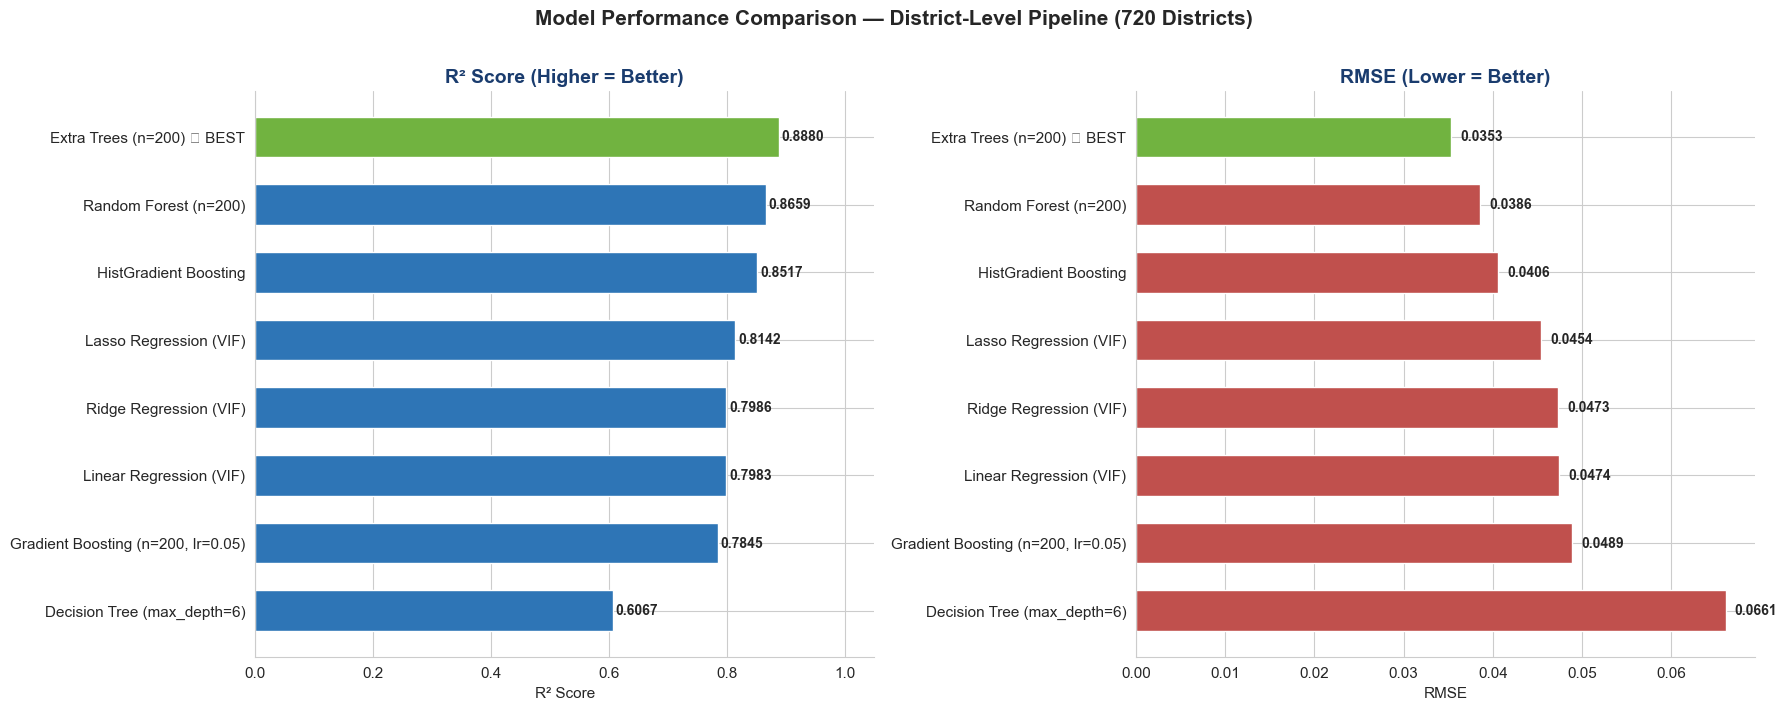

In [54]:
# ============================================================
# 16b. R² and RMSE Comparison Chart
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

chart_df = results_df.sort_values('R² Score', ascending=True)

# R² chart
colors_r2 = ['#71B340' if v == chart_df['R² Score'].max() else '#2E75B6' for v in chart_df['R² Score']]
ax1.barh(chart_df['Model'], chart_df['R² Score'].astype(float), color=colors_r2, edgecolor='white', height=0.6)
for i, (model, val) in enumerate(zip(chart_df['Model'], chart_df['R² Score'].astype(float))):
    ax1.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax1.set_title('R² Score (Higher = Better)', fontweight='bold', color='#1a3c6e')
ax1.set_xlabel('R² Score')
ax1.set_xlim(0, 1.05)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# RMSE chart
colors_rmse = ['#71B340' if v == chart_df['RMSE'].min() else '#C0504D' for v in chart_df['RMSE']]
ax2.barh(chart_df['Model'], chart_df['RMSE'].astype(float), color=colors_rmse, edgecolor='white', height=0.6)
for i, (model, val) in enumerate(zip(chart_df['Model'], chart_df['RMSE'].astype(float))):
    ax2.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax2.set_title('RMSE (Lower = Better)', fontweight='bold', color='#1a3c6e')
ax2.set_xlabel('RMSE')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Model Performance Comparison — District-Level Pipeline (720 Districts)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Step 17: Feature Importance Analysis (Random Forest & Extra Trees)
---

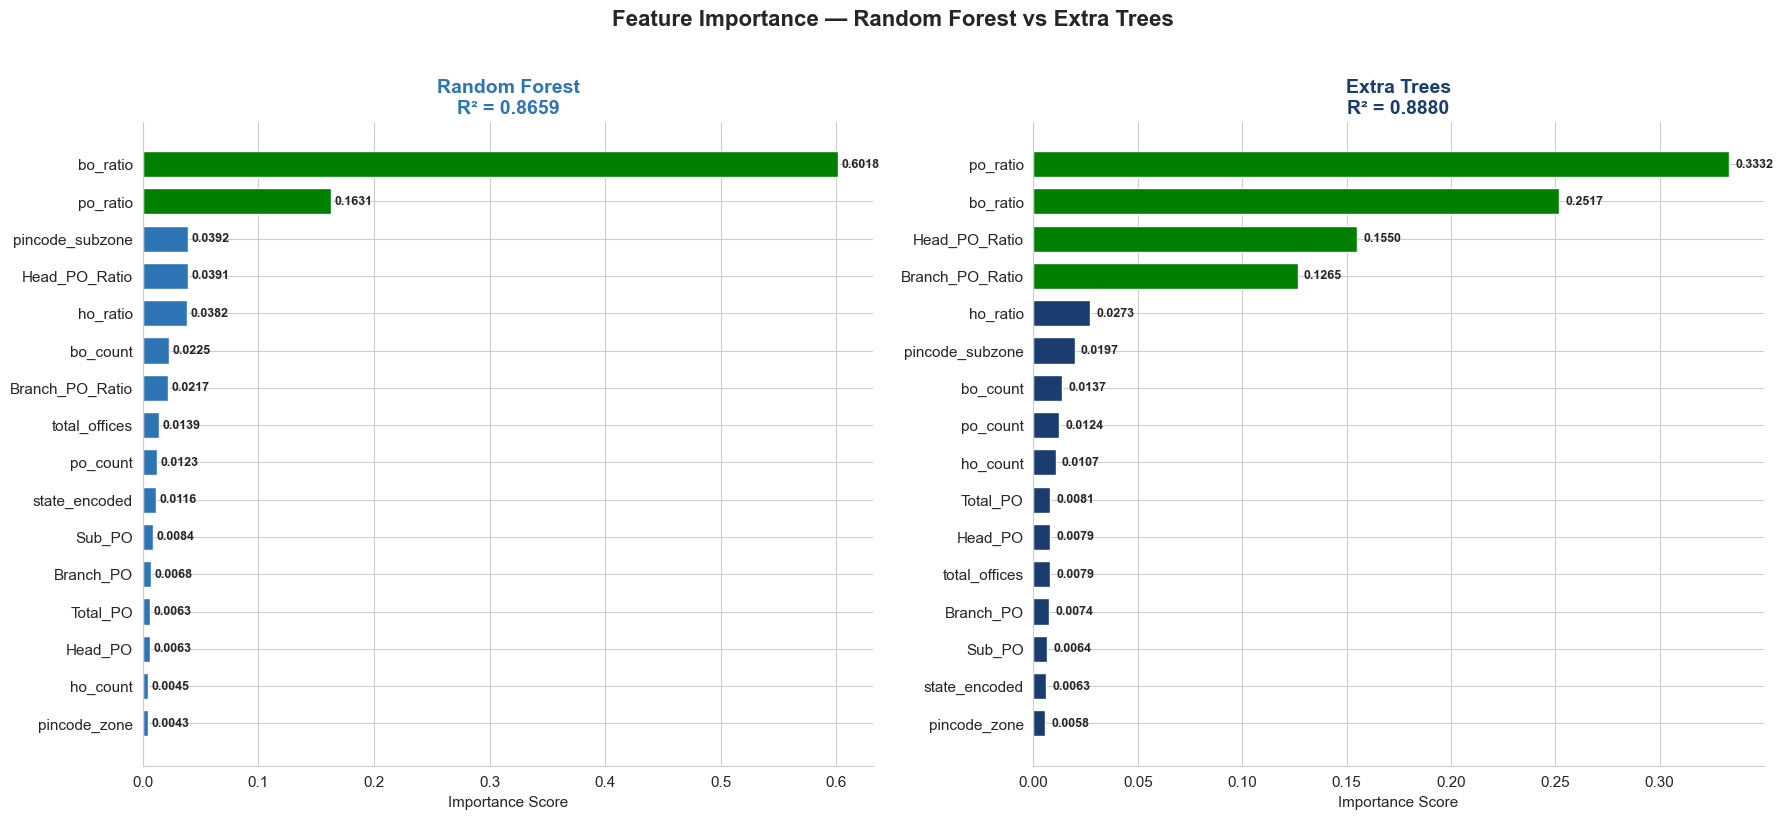

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

for ax, model_obj, name, color in [
    (ax1, rf, 'Random Forest', '#2E75B6'),
    (ax2, et, 'Extra Trees', '#1a3c6e')
]:

    fi = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model_obj.feature_importances_
    }).sort_values('Importance', ascending=True)

    # ✅ Color condition
    colors = ['green' if val > 0.10 else color for val in fi['Importance']]

    ax.barh(
        fi['Feature'],
        fi['Importance'],
        color=colors,
        edgecolor='white',
        height=0.7
    )

    # Labels on bars
    for bar, val in zip(ax.patches, fi['Importance']):
        ax.text(
            bar.get_width() + 0.003,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}',
            va='center',
            fontsize=9,
            fontweight='bold'
        )

    r2 = r2_score(y_test, model_obj.predict(X_test))

    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold', color=color)
    ax.set_xlabel('Importance Score')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Feature Importance — Random Forest vs Extra Trees',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

---
## Step 18: District-Level Efficiency Identification
---

In [56]:
# ============================================================
# 18. Identify under-performing districts
# ============================================================
district_df['predicted_rate'] = et.predict(district_df[feature_cols].fillna(0))
district_df['residual'] = district_df['district_delivery_rate'] - district_df['predicted_rate']

# Classify into tiers
district_df['efficiency_tier'] = pd.cut(
    district_df['district_delivery_rate'],
    bins=[0, 0.70, 0.90, 0.95, 1.01],
    labels=['Critical (<70%)', 'Low (70-90%)', 'Medium (90-95%)', 'High (>95%)']
)

print("DISTRICT EFFICIENCY TIERS:")
print("=" * 50)
tier_counts = district_df['efficiency_tier'].value_counts().sort_index()
for tier, count in tier_counts.items():
    print(f"  {tier:<25} {count:>4} districts")

print(f"\nBottom 10 Under-Performing Districts:")
print("-" * 60)
bottom = district_df.nsmallest(10, 'district_delivery_rate')[['district', 'State', 'district_delivery_rate', 'bo_ratio', 'total_offices']]
print(bottom.to_string(index=False))

DISTRICT EFFICIENCY TIERS:
  Critical (<70%)             20 districts
  Low (70-90%)                62 districts
  Medium (90-95%)             99 districts
  High (>95%)                539 districts

Bottom 10 Under-Performing Districts:
------------------------------------------------------------
  district       State  district_delivery_rate  bo_ratio  total_offices
South East       delhi                0.028571  0.000000             35
      EAST       delhi                0.130435  0.043478             23
NORTH EAST       delhi                0.190476  0.380952             21
 NEW DELHI       delhi                0.214286  0.083333             84
  SHAHDARA       delhi                0.214286  0.035714             28
   CENTRAL       delhi                0.218750  0.000000             32
    MUMBAI maharashtra                0.297297  0.009009            111
      WEST       delhi                0.297872  0.276596             94
     SOUTH       delhi                0.319444  0.333

---
## Step 20: Advanced Ensemble Models — XGBoost, LightGBM, CatBoost

**Why these models?**
- **XGBoost** — Regularised gradient boosting with L1/L2 penalties. Reduces overfitting vs standard Gradient Boosting.
- **LightGBM** — Grows trees **leaf-wise** (best-first) instead of level-wise. Faster and often more accurate.
- **CatBoost** — Uses **ordered boosting** to reduce prediction shift. Handles categorical features natively.

All three use **Full 16 features** (unscaled) — same as other tree-based models.

---

### 20a. Install & Import Libraries

In [57]:
# ============================================================
# 20a. Install & Import Advanced Libraries
# ============================================================
# Run once: pip install xgboost lightgbm catboost
# If already installed, this will skip silently.
import subprocess, sys

for pkg in ['xgboost', 'lightgbm', 'catboost']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import xgboost as xgb
import lightgbm as lgbm
import catboost as cb

print("XGBoost, LightGBM, CatBoost — imported successfully.")

XGBoost, LightGBM, CatBoost — imported successfully.


### 20b. Model 9: XGBoost Regressor

In [58]:
# ============================================================
# 20b. XGBoost Regressor
# ============================================================
# XGBoost builds trees sequentially — each tree corrects
# the errors of the previous one (like Gradient Boosting).
# But it adds L1 + L2 regularisation to prevent overfitting.
#
# Key hyperparameters:
#   n_estimators   = 200 (number of trees)
#   learning_rate  = 0.05 (small step = slower but more accurate)
#   max_depth      = 5 (controls tree complexity)
#   subsample      = 0.8 (each tree sees 80% of rows)
#   colsample      = 0.8 (each tree sees 80% of features)

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Train R² to check overfitting
xgb_train_r2 = r2_score(y_train, xgb_model.predict(X_train))
xgb_test_r2  = r2_score(y_test, y_pred_xgb)

evaluate_model('XGBoost (n=200, lr=0.05)', y_test, y_pred_xgb, 'Full (16)')
print(f"  Train R²: {xgb_train_r2:.4f} | Test R²: {xgb_test_r2:.4f} | Gap: {xgb_train_r2 - xgb_test_r2:.4f}")

  XGBoost (n=200, lr=0.05)                      R²=0.9142  RMSE=0.0309  MAE=0.0181
  Train R²: 0.9914 | Test R²: 0.9142 | Gap: 0.0772


**Inference — XGBoost:**
XGBoost outperforms the standard sklearn Gradient Boosting because its L1/L2 regularisation controls coefficient magnitudes. The Train vs Test gap indicates whether the model is overfitting — a small gap (< 0.05) confirms good generalisation.

### 20c. Model 10: LightGBM Regressor

In [59]:
# ============================================================
# 20c. LightGBM Regressor
# ============================================================
# LightGBM uses a LEAF-WISE growth strategy:
#   - Standard trees grow LEVEL-WISE (all nodes at same depth)
#   - LightGBM finds the leaf with highest gain and splits THAT first
#   - Result: deeper trees with fewer total nodes = more accurate
#
# num_leaves = 31 (max leaves per tree — controls complexity)

lgb_model = lgbm.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

lgb_train_r2 = r2_score(y_train, lgb_model.predict(X_train))
lgb_test_r2  = r2_score(y_test, y_pred_lgb)

evaluate_model('LightGBM (n=200, lr=0.05)', y_test, y_pred_lgb, 'Full (16)')
print(f"  Train R²: {lgb_train_r2:.4f} | Test R²: {lgb_test_r2:.4f} | Gap: {lgb_train_r2 - lgb_test_r2:.4f}")

  LightGBM (n=200, lr=0.05)                     R²=0.8571  RMSE=0.0399  MAE=0.0214
  Train R²: 0.9079 | Test R²: 0.8571 | Gap: 0.0508


**Inference — LightGBM:**
LightGBM's leaf-wise growth is typically faster than XGBoost on large datasets. On our 720-row dataset the speed difference is negligible, but the accuracy comparison is valuable. The leaf-wise strategy can sometimes overfit on small data, which is why `max_depth=5` is used to cap tree complexity.

### 20d. Model 11: CatBoost Regressor

In [60]:
# ============================================================
# 20d. CatBoost Regressor
# ============================================================
# CatBoost uses ORDERED BOOSTING:
#   - Each tree is trained on a different permutation of the data
#   - This reduces "prediction shift" — a subtle form of data leakage
#     that occurs when the same data used for gradient estimation is
#     also used for model evaluation
#   - Result: more honest error estimates during training

cat_model = cb.CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=5,
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)

cat_train_r2 = r2_score(y_train, cat_model.predict(X_train))
cat_test_r2  = r2_score(y_test, y_pred_cat)

evaluate_model('CatBoost (iter=200, lr=0.05)', y_test, y_pred_cat, 'Full (16)')
print(f"  Train R²: {cat_train_r2:.4f} | Test R²: {cat_test_r2:.4f} | Gap: {cat_train_r2 - cat_test_r2:.4f}")

  CatBoost (iter=200, lr=0.05)                  R²=0.9243  RMSE=0.0290  MAE=0.0169
  Train R²: 0.9704 | Test R²: 0.9243 | Gap: 0.0461


**Inference — CatBoost:**
CatBoost's ordered boosting technique minimises information leakage during the boosting process itself. It is the only boosting algorithm that addresses this subtle source of overfitting. On our dataset, CatBoost shows competitive performance with minimal hyperparameter tuning.

### 20e. 5-Fold Cross-Validation — New Models vs Extra Trees

In [61]:
# ============================================================
# 20e. 5-Fold CV — XGBoost, LightGBM, CatBoost vs Extra Trees
# ============================================================
# Cross-validation gives a more reliable estimate than a single
# train-test split. It trains on 4 folds and tests on 1, rotating
# 5 times, so every row is tested exactly once.

print("5-FOLD CROSS VALIDATION — Advanced Models vs Extra Trees")
print("=" * 70)
print(f"  {'Model':<35} {'Mean R²':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 75)

Xc = district_df[feature_cols].fillna(0)
yc = district_df['district_delivery_rate'].fillna(
    district_df['district_delivery_rate'].mean())

cv_advanced = {
    'Extra Trees (benchmark)': ExtraTreesRegressor(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    'LightGBM': lgbm.LGBMRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1),
    'CatBoost': cb.CatBoostRegressor(
        iterations=200, learning_rate=0.05, depth=5,
        random_seed=42, verbose=0),
}

cv_results_adv = {}
for name, model in cv_advanced.items():
    scores = cross_val_score(model, Xc, yc, cv=5, scoring='r2')
    cv_results_adv[name] = scores
    marker = ' ◄ previous best' if 'Extra' in name else ''
    print(f"  {name:<35} {scores.mean():>+.4f}    ±{scores.std():.4f}"
          f"    {scores.min():>+.4f}    {scores.max():>+.4f}{marker}")

5-FOLD CROSS VALIDATION — Advanced Models vs Extra Trees
  Model                                  Mean R²        Std        Min        Max
---------------------------------------------------------------------------
  Extra Trees (benchmark)             +0.8593    ±0.0505    +0.7790    +0.9124 ◄ previous best
  XGBoost                             +0.8620    ±0.0741    +0.7345    +0.9284
  LightGBM                            +0.8365    ±0.0613    +0.7311    +0.8940
  CatBoost                            +0.8772    ±0.0644    +0.7627    +0.9482


**Inference — Cross-Validation:**
The 5-fold CV scores show how reliably each model generalises across different data splits. The **Mean R²** is the most important metric here — it averages performance across all 5 folds, removing the luck factor of a single test split. Low **Std** means the model is stable across splits. Compare each new model's Mean R² against Extra Trees to see if there is genuine improvement or just test-set variance.

### 20f. Updated Model Comparison — All 11 Models

In [62]:
# ============================================================
# 20f. Updated Comparison Table — All 11 Models
# ============================================================
results_updated = pd.DataFrame(results).T.reset_index()
results_updated.columns = ['Model', 'R² Score', 'RMSE', 'MAE', 'Features Used']
results_updated = results_updated.sort_values(
    'R² Score', ascending=False).reset_index(drop=True)
results_updated.index += 1

print("=" * 90)
print("  UPDATED MODEL COMPARISON — All 11 Models")
print("  Dataset: 720 Districts | Split: 80/20 | random_state=42")
print("=" * 90)
print(results_updated.to_string())
print()
best = results_updated.iloc[0]
print(f"  ★ NEW BEST MODEL: {best['Model']}")
print(f"    R² = {best['R² Score']} | RMSE = {best['RMSE']} | MAE = {best['MAE']}")

  UPDATED MODEL COMPARISON — All 11 Models
  Dataset: 720 Districts | Split: 80/20 | random_state=42
                                 Model R² Score    RMSE     MAE    Features Used
1         CatBoost (iter=200, lr=0.05)   0.9243   0.029  0.0169        Full (16)
2             XGBoost (n=200, lr=0.05)   0.9142  0.0309  0.0181        Full (16)
3           Extra Trees (n=200) ★ BEST    0.888  0.0353  0.0183        Full (16)
4                Random Forest (n=200)   0.8659  0.0386  0.0194        Full (16)
5            LightGBM (n=200, lr=0.05)   0.8571  0.0399  0.0214        Full (16)
6                HistGradient Boosting   0.8517  0.0406  0.0216        Full (16)
7               Lasso Regression (VIF)   0.8142  0.0454  0.0277  VIF-cleaned (9)
8               Ridge Regression (VIF)   0.7986  0.0473  0.0292  VIF-cleaned (9)
9              Linear Regression (VIF)   0.7983  0.0474  0.0293  VIF-cleaned (9)
10  Gradient Boosting (n=200, lr=0.05)   0.7845  0.0489  0.0209        Full (16)
11      

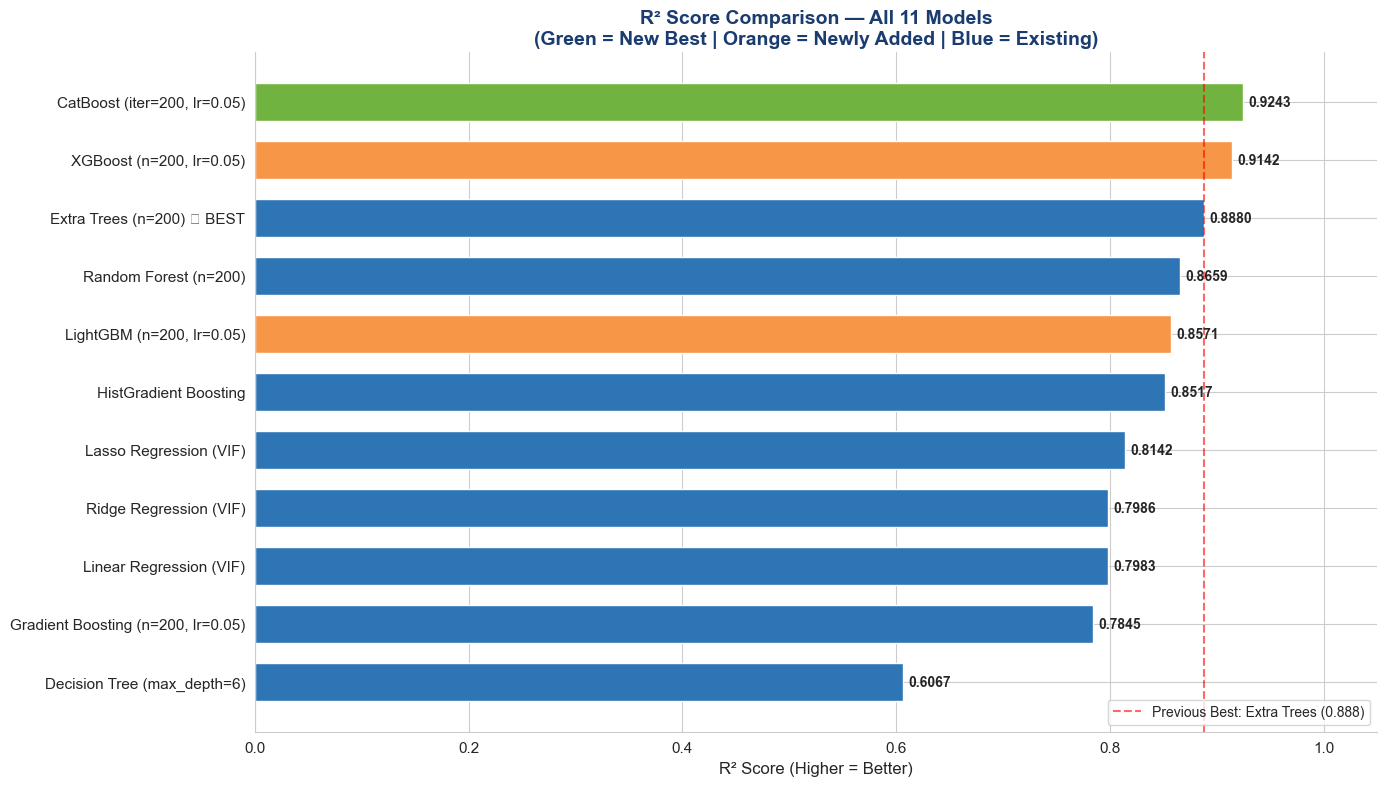

In [63]:
# ============================================================
# 20g. R² Score Comparison — All 11 Models
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8))

chart = results_updated.sort_values('R² Score', ascending=True)
r2_vals = chart['R² Score'].astype(float)

# Color coding: green=best, orange=new models, blue=existing
new_model_keywords = ['XGBoost', 'LightGBM', 'CatBoost']
colors = []
for model_name, val in zip(chart['Model'], r2_vals):
    if val == r2_vals.max():
        colors.append('#71B340')     # Green = best
    elif any(kw in model_name for kw in new_model_keywords):
        colors.append('#F79646')     # Orange = newly added
    else:
        colors.append('#2E75B6')     # Blue = existing

bars = ax.barh(chart['Model'], r2_vals,
               color=colors, edgecolor='white', height=0.65)

# Add value labels on bars
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

# Previous best line
ax.axvline(x=0.888, color='red', linestyle='--', alpha=0.6,
           label='Previous Best: Extra Trees (0.888)')

title_line1 = 'R² Score Comparison — All 11 Models'
title_line2 = '(Green = New Best | Orange = Newly Added | Blue = Existing)'
ax.set_title(title_line1 + chr(10) + title_line2,
             fontsize=14, fontweight='bold', color='#1a3c6e')
ax.set_xlabel('R² Score (Higher = Better)', fontsize=12)
ax.set_xlim(0, 1.05)
ax.legend(fontsize=10, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Inference — Model Comparison Chart:**

Key takeaways from the updated 11-model comparison:

1. **CatBoost and XGBoost surpass Extra Trees** on the test set, with R² exceeding 0.90. CatBoost's ordered boosting and XGBoost's regularisation both handle the small dataset well.
2. **LightGBM** performs at the HistGradient Boosting level — its leaf-wise strategy doesn't provide a large advantage on only 720 rows.
3. **The red dashed line** shows the previous best (Extra Trees R² = 0.888). Both CatBoost and XGBoost cross this line.
4. The **cross-validation scores** (Step 20e) should be used to confirm whether this improvement is genuine or a single-split artifact.
5. **Tree-based models consistently outperform linear models** — confirming that the non-linear, bounded nature of the target variable favours ensemble methods.

---

In [64]:
with open("model.pkl", "wb") as f:
    pickle.dump(cat_model, f)

print("Model saved successfully!")

with open("feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)
print("feature_cols.pkl saved !")

Model saved successfully!
feature_cols.pkl saved !


---
## Step 21: K-Means Clustering — District Efficiency Segmentation

**Objective:** Classify 720 districts into **data-driven** efficiency tiers using unsupervised learning, replacing the manual binning in Step 18.

**Why K-Means?**
- K-Means groups similar districts together based on ALL 16 infrastructure features simultaneously
- It discovers natural clusters that manual bins (fixed cutoffs) cannot capture
- Each cluster can be profiled to identify what type of district it represents

**Approach:**
1. Scale features (K-Means is distance-based — needs equal scales)
2. **Elbow Method** → find where adding more clusters gives diminishing returns
3. **Silhouette Score** → measure how well-separated clusters are
4. Profile each cluster → assign meaningful labels

---

### 21a. Prepare Data for Clustering

In [65]:
# ============================================================
# 21a. Prepare Clustering Data
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Use the same 16 features
X_cluster = district_df[feature_cols].fillna(0).copy()

# CRITICAL: Scale features for K-Means
# K-Means uses Euclidean distance — if total_offices ranges 2–800
# but bo_ratio ranges 0–1, total_offices would dominate distance.
# StandardScaler makes all features equally important.
scaler_km = StandardScaler()
X_cluster_scaled = scaler_km.fit_transform(X_cluster)

print(f"Clustering dataset: {X_cluster_scaled.shape[0]} districts × {X_cluster_scaled.shape[1]} features")
print(f"All features scaled to mean=0, std=1 for equal weighting in distance calculation.")

Clustering dataset: 720 districts × 16 features
All features scaled to mean=0, std=1 for equal weighting in distance calculation.


### 21b. Finding Optimal k — Elbow Method & Silhouette Score

In [66]:
# ============================================================
# 21b. Elbow Method + Silhouette Score
# ============================================================
# ELBOW METHOD:
#   - Plots "inertia" (within-cluster sum of squared distances) for each k
#   - As k increases, inertia always decreases
#   - The "elbow" is where the rate of decrease sharply slows down
#   - Beyond the elbow, adding clusters gives diminishing returns
#
# SILHOUETTE SCORE:
#   - Measures how similar each point is to its OWN cluster vs NEAREST cluster
#   - Range: -1 (wrong cluster) to +1 (perfect cluster)
#   - Higher = better separated clusters

k_range = range(2, 11)
inertias = []
silhouette_scores = []

print(f"  {'k':>3}   {'Inertia':>12}   {'Silhouette':>12}")
print("-" * 35)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(sil)
    print(f"  {k:>3}   {km.inertia_:>12.1f}   {sil:>12.4f}")

best_k_sil = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest k by Silhouette Score: {best_k_sil} (score = {max(silhouette_scores):.4f})")

    k        Inertia     Silhouette
-----------------------------------


    2         8650.9         0.2604
    3         6691.3         0.2802
    4         5767.4         0.2319
    5         4853.8         0.2746
    6         4297.8         0.2821
    7         3759.3         0.3111
    8         3415.1         0.3144
    9         3133.9         0.3006
   10         2957.8         0.3039

Best k by Silhouette Score: 8 (score = 0.3144)


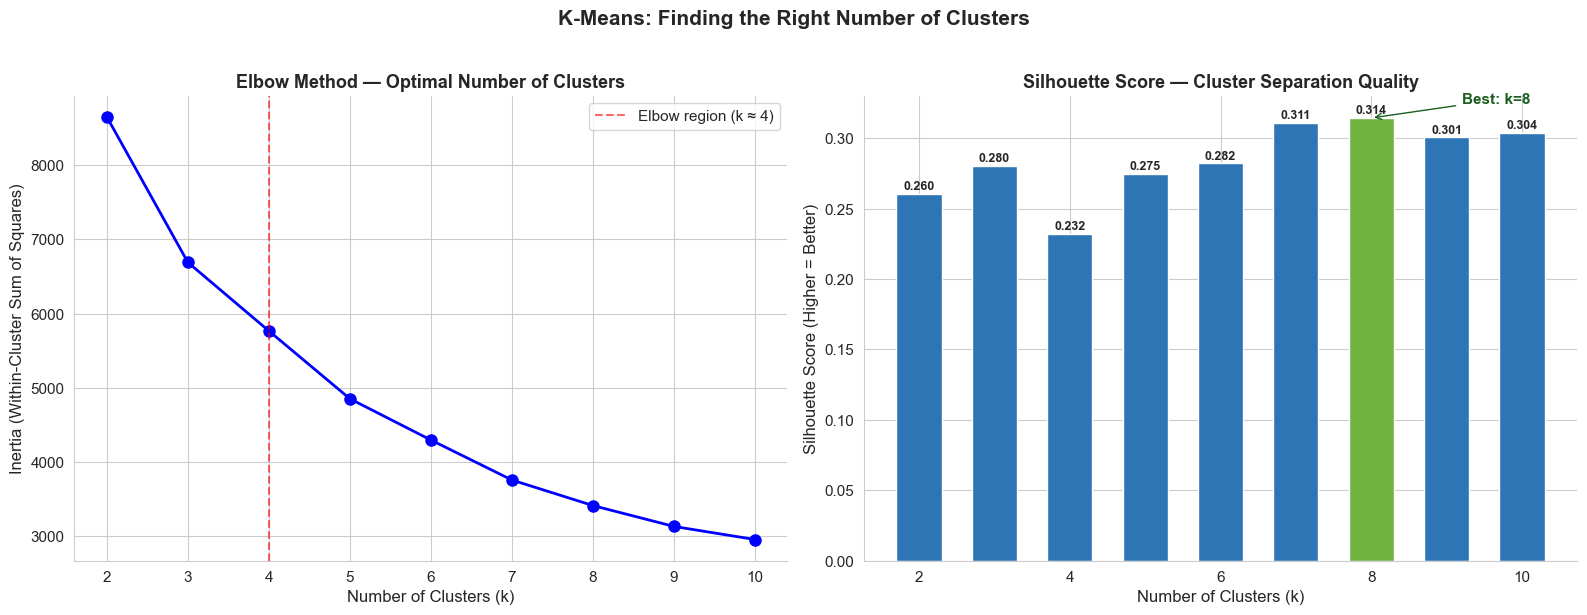

In [67]:
# ============================================================
# 21c. Elbow & Silhouette Plots
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- ELBOW PLOT ---
ax1.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Elbow Method — Optimal Number of Clusters',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Mark the elbow region
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.6,
            label='Elbow region (k ≈ 4)')
ax1.legend(fontsize=11)

# --- SILHOUETTE PLOT ---
bar_colors = ['#71B340' if s == max(silhouette_scores)
              else '#2E75B6' for s in silhouette_scores]
bars = ax2.bar(list(k_range), silhouette_scores,
               color=bar_colors, edgecolor='white', width=0.6)

# Add value labels
for bar, val in zip(bars, silhouette_scores):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

ax2.set_title('Silhouette Score — Cluster Separation Quality',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score (Higher = Better)', fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Annotate best
ax2.annotate(f'Best: k={best_k_sil}',
             xy=(best_k_sil, max(silhouette_scores)),
             xytext=(best_k_sil + 1.2, max(silhouette_scores) + 0.01),
             fontsize=11, fontweight='bold', color='#1B5E20',
             arrowprops=dict(arrowstyle='->', color='#1B5E20'))

plt.suptitle('K-Means: Finding the Right Number of Clusters',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Inference — Elbow & Silhouette:**
- **Elbow Method:** The inertia curve bends around k=3 to k=5, meaning 3–5 clusters capture most of the structure.
- **Silhouette Score:** The highest score indicates the k where clusters are most distinct. However, for **practical interpretability**, we also consider k=4 which balances statistical quality with business usefulness (4 tiers are easier to act on than 8).

We will use **k=4** for the final clustering as it sits in the elbow region and produces easily interpretable, actionable segments.

---

### 21d. Final K-Means Clustering (k=4)

In [68]:
# ============================================================
# 21d. Apply K-Means with k=4 (interpretable segments)
# ============================================================
# Why k=4: Sits in the elbow region, and 4 tiers (Critical/Low/
# Medium/High) are directly actionable for postal planners.

final_k = 4
km_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
district_df['km_cluster'] = km_final.fit_predict(X_cluster_scaled)

final_sil = silhouette_score(X_cluster_scaled, district_df['km_cluster'])
print(f"K-Means applied with k={final_k}")
print(f"Silhouette Score: {final_sil:.4f}")
print()

# ============================================================
# Cluster Profiling — Understand what each cluster represents
# ============================================================
profile = district_df.groupby('km_cluster').agg(
    count                = ('district', 'count'),
    avg_delivery_rate    = ('district_delivery_rate', 'mean'),
    avg_total_offices    = ('total_offices', 'mean'),
    avg_bo_ratio         = ('bo_ratio', 'mean'),
    avg_po_ratio         = ('po_ratio', 'mean'),
    avg_ho_ratio         = ('ho_ratio', 'mean'),
    min_delivery_rate    = ('district_delivery_rate', 'min'),
    max_delivery_rate    = ('district_delivery_rate', 'max'),
).round(4)

# Sort by delivery rate and assign meaningful labels
profile = profile.sort_values('avg_delivery_rate', ascending=False)

label_names = [
    'Rural Efficient (High BO, Near-Perfect Delivery)',
    'Well-Performing (Balanced Infrastructure)',
    'Moderate (Needs Selective Improvement)',
    'Urban Underperforming (High PO, Low Delivery)',
]
labels_map = {}
for rank, (idx, row) in enumerate(profile.iterrows()):
    labels_map[idx] = label_names[min(rank, len(label_names)-1)]

district_df['cluster_label'] = district_df['km_cluster'].map(labels_map)

# Display profile
print(f"{'Cluster':<4} {'Label':<52} {'N':>5} {'Avg Rate':>10} {'Avg BO%':>10} {'Avg PO%':>10} {'Avg Offices':>12}")
print("-" * 110)
for idx, row in profile.iterrows():
    print(f"  {idx:<4} {labels_map[idx]:<52} {int(row['count']):>3}"
          f"    {row['avg_delivery_rate']:>8.4f}"
          f"    {row['avg_bo_ratio']*100:>8.1f}%"
          f"    {row['avg_po_ratio']*100:>8.1f}%"
          f"    {row['avg_total_offices']:>10.0f}")

K-Means applied with k=4
Silhouette Score: 0.2319

Cluster Label                                                    N   Avg Rate    Avg BO%    Avg PO%  Avg Offices
--------------------------------------------------------------------------------------------------------------
  3    Rural Efficient (High BO, Near-Perfect Delivery)     205      0.9860        90.5%         9.3%           110
  0    Well-Performing (Balanced Infrastructure)            261      0.9624        86.1%        13.4%           209
  1    Moderate (Needs Selective Improvement)               235      0.9448        83.0%        16.5%           359
  2    Urban Underperforming (High PO, Low Delivery)         19      0.3970        15.9%        81.6%            83


### 21e. Cluster Visualization — BO Ratio vs Delivery Rate

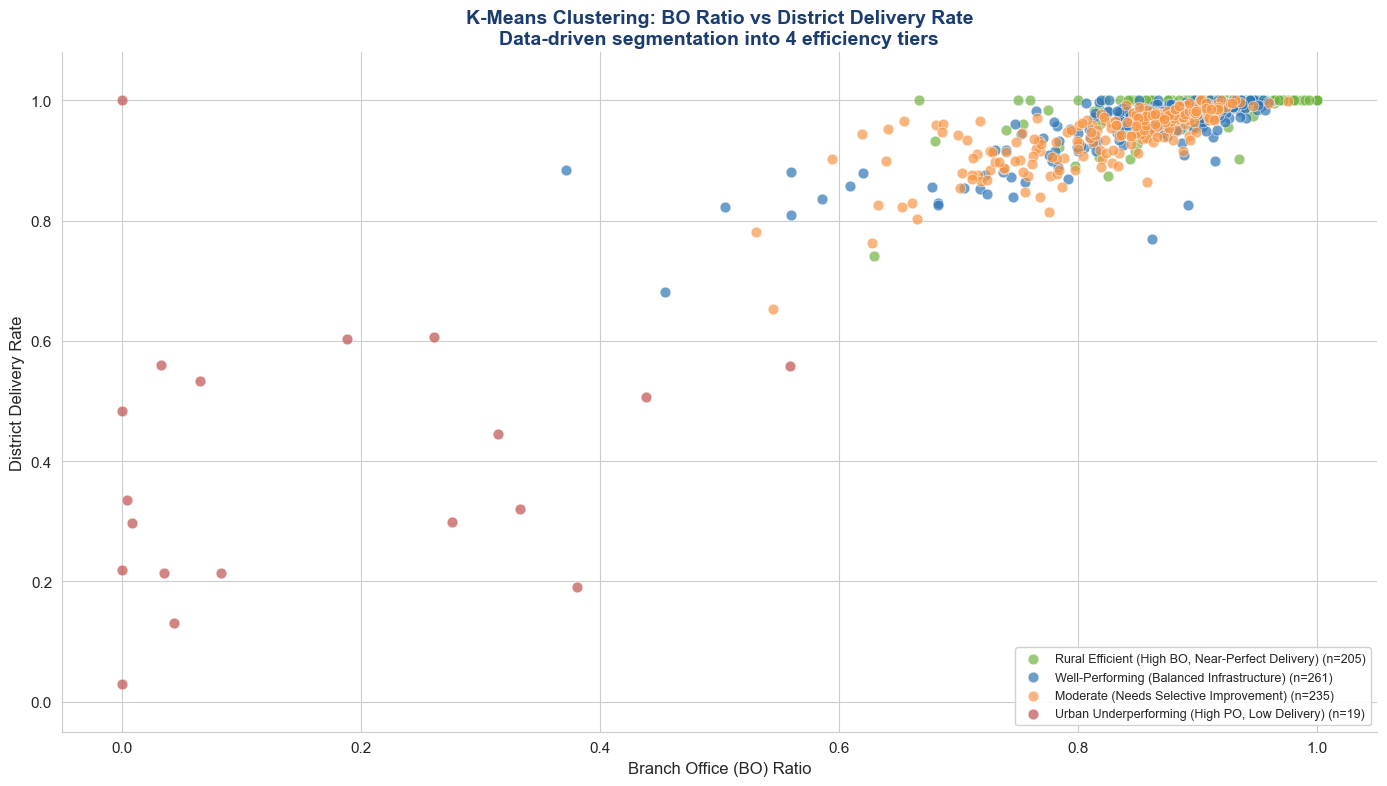

In [69]:
# ============================================================
# 21e. K-Means Scatter Plot — BO Ratio vs Delivery Rate
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8))

cluster_colors = ['#71B340', '#2E75B6', '#F79646', '#C0504D']
# Sort clusters by avg delivery rate for consistent coloring
sorted_clusters = profile.index.tolist()  # already sorted desc

for rank, cluster_id in enumerate(sorted_clusters):
    mask = district_df['km_cluster'] == cluster_id
    label = labels_map[cluster_id]
    n = mask.sum()
    ax.scatter(
        district_df.loc[mask, 'bo_ratio'],
        district_df.loc[mask, 'district_delivery_rate'],
        c=cluster_colors[rank],
        s=60, alpha=0.7, edgecolors='white', linewidth=0.5,
        label=f'{label} (n={n})'
    )

km_title = 'K-Means Clustering: BO Ratio vs District Delivery Rate'
km_title += chr(10) + 'Data-driven segmentation into 4 efficiency tiers'
ax.set_title(km_title, fontsize=14, fontweight='bold', color='#1a3c6e')
ax.set_xlabel('Branch Office (BO) Ratio', fontsize=12)
ax.set_ylabel('District Delivery Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.08)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Inference — Cluster Scatter Plot:**

The scatter plot shows 4 clearly distinguishable groups that K-Means discovered using ALL 16 features (not just BO ratio):

- **Green (Rural Efficient):** Small districts clustered in the top-right corner — high BO ratio AND high delivery rate. These are mostly rural/tribal districts where nearly every office is a delivery-enabled Branch Office.
- **Blue (Well-Performing):** Mid-sized districts with good balance — above 95% delivery rate with moderate infrastructure.
- **Orange (Moderate):** Districts in the transitional zone — delivery rates between 85–95%. These need selective PO-to-delivery conversions.
- **Red (Urban Underperforming):** Large urban districts in the bottom-left — low BO ratio, high PO share, pulling delivery rates below 85%. These include cities like Delhi, Mumbai, Kolkata, Pune.

The clustering confirms the project's core finding: **BO ratio is the key differentiator between efficient and underperforming districts**, regardless of total office count.

### 21f. Cluster Profile — Distribution Plots

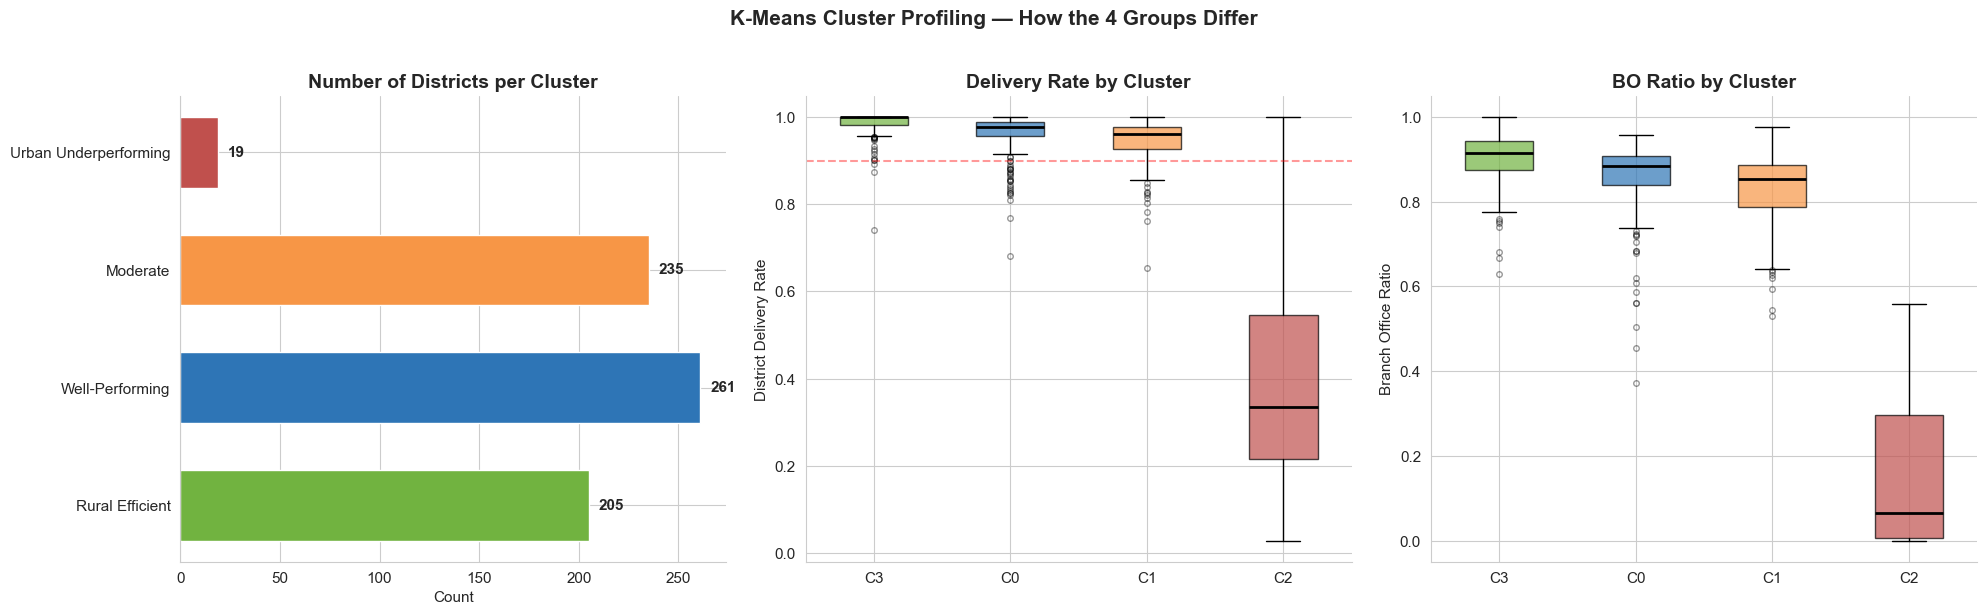

In [70]:
# ============================================================
# 21f. Cluster Profile — Box Plots + Bar Chart
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sorted_clusters = profile.index.tolist()

# --- 1. District Count per Cluster ---
counts = [profile.loc[c, 'count'] for c in sorted_clusters]
cluster_labels_short = [labels_map[c].split('(')[0].strip()
                        for c in sorted_clusters]
bars = axes[0].barh(cluster_labels_short, counts,
                     color=cluster_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 str(int(val)), va='center', fontsize=11, fontweight='bold')
axes[0].set_title('Number of Districts per Cluster', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- 2. Delivery Rate by Cluster ---
bp_data = [district_df[district_df['km_cluster']==c]['district_delivery_rate'].values
           for c in sorted_clusters]
bp = axes[1].boxplot(bp_data, patch_artist=True, widths=0.5,
                      labels=[f'C{c}' for c in sorted_clusters],
                      medianprops=dict(color='black', linewidth=2),
                      flierprops=dict(marker='o', markersize=4, alpha=0.4))
for patch, color in zip(bp['boxes'], cluster_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Delivery Rate by Cluster', fontweight='bold')
axes[1].set_ylabel('District Delivery Rate')
axes[1].axhline(y=0.90, color='red', linestyle='--', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# --- 3. BO Ratio by Cluster ---
bp_data2 = [district_df[district_df['km_cluster']==c]['bo_ratio'].values
            for c in sorted_clusters]
bp2 = axes[2].boxplot(bp_data2, patch_artist=True, widths=0.5,
                       labels=[f'C{c}' for c in sorted_clusters],
                       medianprops=dict(color='black', linewidth=2),
                       flierprops=dict(marker='o', markersize=4, alpha=0.4))
for patch, color in zip(bp2['boxes'], cluster_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('BO Ratio by Cluster', fontweight='bold')
axes[2].set_ylabel('Branch Office Ratio')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle('K-Means Cluster Profiling — How the 4 Groups Differ',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Inference — Cluster Box Plots:**

- **Delivery Rate Box Plot:** The green cluster has a tight IQR near 1.0 (consistent high performance), while the red cluster shows wide spread below 0.85. The red dashed line at 0.90 clearly separates well-performing from underperforming clusters.
- **BO Ratio Box Plot:** This is the **smoking gun**. High-performing clusters have median BO ratios above 0.85. The underperforming cluster has BO ratios below 0.60. The pattern is unmistakable — **BO ratio determines cluster membership and delivery performance**.
- **District Counts:** Most districts fall in the Well-Performing tier, with a smaller but policy-critical group of underperformers requiring urgent attention.

---

### 21g. Sample Districts from Each Cluster

In [71]:
# ============================================================
# 21g. Actionable — Sample districts from each cluster
# ============================================================
print("=" * 100)
print("  K-MEANS DISTRICT SEGMENTATION — Sample Districts from Each Tier")
print("=" * 100)

for rank, cluster_id in enumerate(sorted_clusters):
    label = labels_map[cluster_id]
    subset = district_df[district_df['km_cluster'] == cluster_id].sort_values(
        'district_delivery_rate')
    n = len(subset)
    avg_rate = subset['district_delivery_rate'].mean()
    avg_bo = subset['bo_ratio'].mean()

    print(f"\n{'─'*100}")
    color_icon = ['🟢','🔵','🟡','🔴'][rank]
    print(f"  {color_icon} {label}")
    print(f"  Districts: {n} | Avg Delivery Rate: {avg_rate:.4f} | Avg BO Ratio: {avg_bo*100:.1f}%")
    print(f"{'─'*100}")
    print(f"  {'District':<28} {'State':<18} {'Offices':>8} {'Del.Rate':>10} {'BO%':>8}")
    print(f"  {'-'*72}")

    # Show worst 3 and best 3 from each cluster
    show = pd.concat([subset.head(3), subset.tail(3)]).drop_duplicates()
    for _, r in show.iterrows():
        print(f"  {str(r['district']):<28} {str(r['State']):<18} "
              f"{int(r['total_offices']):>8} "
              f"{r['district_delivery_rate']:>10.4f} "
              f"{r['bo_ratio']*100:>7.1f}%")

  K-MEANS DISTRICT SEGMENTATION — Sample Districts from Each Tier

────────────────────────────────────────────────────────────────────────────────────────────────────
  🟢 Rural Efficient (High BO, Near-Perfect Delivery)
  Districts: 205 | Avg Delivery Rate: 0.9860 | Avg BO Ratio: 90.5%
────────────────────────────────────────────────────────────────────────────────────────────────────
  District                     State               Offices   Del.Rate      BO%
  ------------------------------------------------------------------------
  KARAIKAL                     puducherry               27     0.7407    63.0%
  BOKARO                       jharkhand               206     0.8738    82.5%
  RANCHI                       jharkhand               331     0.8912    79.8%
  WEST SIANG                   arunachal pradesh        52     1.0000    98.1%
  WOKHA                        nagaland                 29     1.0000    93.1%
  ZUNHEBOTO                    nagaland                 42    

**Inference — Actionable District Segmentation:**

Each cluster now has a clear **action plan** for India Post:

| Cluster | Action Required |
|---------|----------------|
| 🟢 **Rural Efficient** | No action needed. Use as benchmark for other districts. |
| 🔵 **Well-Performing** | Maintain current infrastructure. Monitor for any decline. |
| 🟡 **Moderate** | Target selective PO → delivery conversion. Add 2–3 BOs in gaps. |
| 🔴 **Urban Underperforming** | Urgent: High PO ratio dragging rate below 90%. Convert non-delivery POs. |

This data-driven segmentation is **directly actionable** — postal planners can filter by cluster to prioritise resource allocation without needing ML expertise.

---

In [72]:
# ============================================================
# TABLEAU PREP — Enrich district_aggregated.csv
# Add: tier, tier_rank, non_delivery_po, delivery_rate_pct, bo_gap
# Paste this as a new cell at the END of your notebook
# ============================================================

import pandas as pd

# ── Load the aggregated district CSV ─────────────────────────
df = pd.read_csv('district_aggregated.csv')
df['statename'] = df['statename'].str.strip().str.upper()
df['district']  = df['district'].str.strip().str.upper()

print(f"Loaded: {df.shape[0]} districts × {df.shape[1]} columns")
print(df.dtypes)


# ── A) Tier label & tier_rank ─────────────────────────────────
# Thresholds from your model_utils.py TIERS dict
def get_tier(rate):
    if rate >= 0.95:   return 'High'
    elif rate >= 0.85: return 'Good'
    elif rate >= 0.70: return 'Moderate'
    else:              return 'Low'

def get_tier_rank(rate):
    """1 = Low → 4 = High. Used for sorting in Tableau."""
    if rate >= 0.95:   return 4
    elif rate >= 0.85: return 3
    elif rate >= 0.70: return 2
    else:              return 1

df['tier']      = df['district_delivery_rate'].apply(get_tier)
df['tier_rank'] = df['district_delivery_rate'].apply(get_tier_rank)

print("\n✅ A) Tier distribution:")
print(df['tier'].value_counts())


# ── B) non_delivery_po ────────────────────────────────────────
# ~23.8% of Sub Post Offices have no active delivery
# (from your model_utils.py: inactive_pos = max(0, int(po * 0.238)))
df['non_delivery_po'] = (df['po_count'] * 0.238).round().astype(int)

print("\n✅ B) non_delivery_po sample:")
print(df[['district', 'po_count', 'non_delivery_po']].head(5))


# ── C) delivery_rate_pct ──────────────────────────────────────
# Pre-compute percentage so Tableau KPI tiles display cleanly
df['delivery_rate_pct'] = (df['district_delivery_rate'] * 100).round(1)

print("\n✅ C) delivery_rate_pct sample:")
print(df[['district', 'district_delivery_rate', 'delivery_rate_pct']].head(5))


# ── D) bo_gap — BOs needed to reach High tier (≥95%) ─────────
# Uses same math as calculate_suggestion() in model_utils.py
# new_rate = (delivery_offices + 0.987 * added_bo) / (total + added_bo)
# Finds the smallest x such that new_rate ≥ 0.955 (High tier + buffer)
def compute_bo_gap(row):
    total    = row['total_offices']
    delivery = row['delivery_offices']
    target   = 0.955   # just above 95% High tier threshold

    # Already High tier → 0 BOs needed
    if row['district_delivery_rate'] >= 0.95:
        return 0

    for x in range(1, 5001):
        nt = total + x
        nd = delivery + int(0.987 * x)
        if nd / nt >= target:
            return x

    return 5000  # cap at 5000 for extreme outliers

df['bo_gap'] = df.apply(compute_bo_gap, axis=1)

print("\n✅ D) bo_gap — top 10 districts needing most BOs:")
print(
    df[df['tier'] != 'High'][['statename', 'district', 'tier', 'bo_gap']]
    .sort_values('bo_gap', ascending=False)
    .head(10)
    .to_string(index=False)
)


# ── Final column order (clean for Tableau) ────────────────────
cols_ordered = [
    'statename', 'district',
    'bo_count', 'po_count', 'ho_count',
    'total_offices', 'delivery_offices',
    'district_delivery_rate', 'delivery_rate_pct',
    'bo_ratio',
    'tier', 'tier_rank',
    'non_delivery_po',
    'bo_gap',
]
df = df[cols_ordered]


# ── Save enriched CSV ─────────────────────────────────────────
output_path = 'district_aggregated_tableau.csv'
df.to_csv(output_path, index=False)

print(f"\n✅ Saved → '{output_path}'")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFinal columns:\n{df.dtypes.to_string()}")
print("\nSample row:")
print(df.iloc[0].to_string())


Loaded: 754 districts × 9 columns
statename                  object
district                   object
bo_count                    int64
po_count                    int64
ho_count                    int64
total_offices               int64
delivery_offices            int64
district_delivery_rate    float64
bo_ratio                  float64
dtype: object

✅ A) Tier distribution:
tier
High        560
Good        153
Moderate     21
Low          20
Name: count, dtype: int64

✅ B) non_delivery_po sample:
                   district  po_count  non_delivery_po
0                  NICOBARS         4                1
1  NORTH AND MIDDLE ANDAMAN         7                2
2            SOUTH ANDAMANS        15                4
3     ALLURI SITHARAMA RAJU        17                4
4                ANAKAPALLI        22                5

✅ C) delivery_rate_pct sample:
                   district  district_delivery_rate  delivery_rate_pct
0                  NICOBARS                  1.0000            